# Analysis of different aggregation functions for EIP-8037

#### Maria Silva, February 2026

In [112]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

In [113]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

# output folder
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))
src_dir = os.path.join(repo_dir, "src")
our_dir = os.path.join(repo_dir, "reports", "figures", "8037_agg_funs_report")

In [114]:
sys.path.append(src_dir)
import state_growth

## Repricing impact for 5x gas limit and 18x price increase

#### Parameters

- $n=5$
- $m=18$
- $s=0.4$
- $G^0=60$ (in million gas units)
- $b^0=1$ (in gwei)
- State growth is 325 MiB per day $\implies$ $S^0 = \frac{325 \cdot 1048576 \cdot 12}{60 \cdot 60 \cdot 24}$ bytes
- $\varepsilon_s,\varepsilon_b  \in [0.1, 1.5]$



In [115]:
n = 5
m = 18
s = 0.4
G_0 = 60
b_0 = 1.0
S_0 = (325 * 1048576 * 12) / (60 * 60 * 24)
results_list = []

for eps_s in np.linspace(0.1, 1.5, 10):
    for eps_b in np.linspace(0.1, 1.5, 10):
        # Find equilibrium for sum function
        b_star_sum = state_growth.find_equilibrium_base_fee_sum(
            m, n, eps_s, eps_b, b_0, s
        )
        # Compute usage and shares for sum function
        results = state_growth.compute_equilibrium_stats(
            b_star_sum, m, n, eps_s, eps_b, G_0, b_0, S_0, s
        )
        results["eps_s"] = eps_s.round(2).astype(str)
        results["eps_b"] = eps_b.round(2).astype(str)
        results["agg_function"] = "sum"
        results_list.append(results)
        # Find equilibrium for max function
        b_star_max = state_growth.find_equilibrium_base_fee_max(
            m, n, eps_s, eps_b, b_0, s
        )
        # Compute usage and shares for max function
        results = state_growth.compute_equilibrium_stats(
            b_star_max, m, n, eps_s, eps_b, G_0, b_0, S_0, s
        )
        results["eps_s"] = eps_s.round(2).astype(str)
        results["eps_b"] = eps_b.round(2).astype(str)
        results["agg_function"] = "max"
        results_list.append(results)
        # Find equilibrium for burst function
        b_star_burst = state_growth.find_equilibrium_base_fee_burst(
            m, n, eps_s, eps_b, b_0, s
        )
        # Compute usage and shares for burst function
        results = state_growth.compute_equilibrium_stats(
            b_star_burst, m, n, eps_s, eps_b, G_0, b_0, S_0, s
        )
        results["eps_s"] = eps_s.round(2).astype(str)
        results["eps_b"] = eps_b.round(2).astype(str)
        results["agg_function"] = "burst"
        results_list.append(results)

results_df = pd.DataFrame(results_list)
results_df["burst_throughput_gain"] = results_df["burst_throughput_s"] / (1 - s)
results_df["is_state_limited"] = results_df["limiting_resource"] == "state"

### Limiting resource

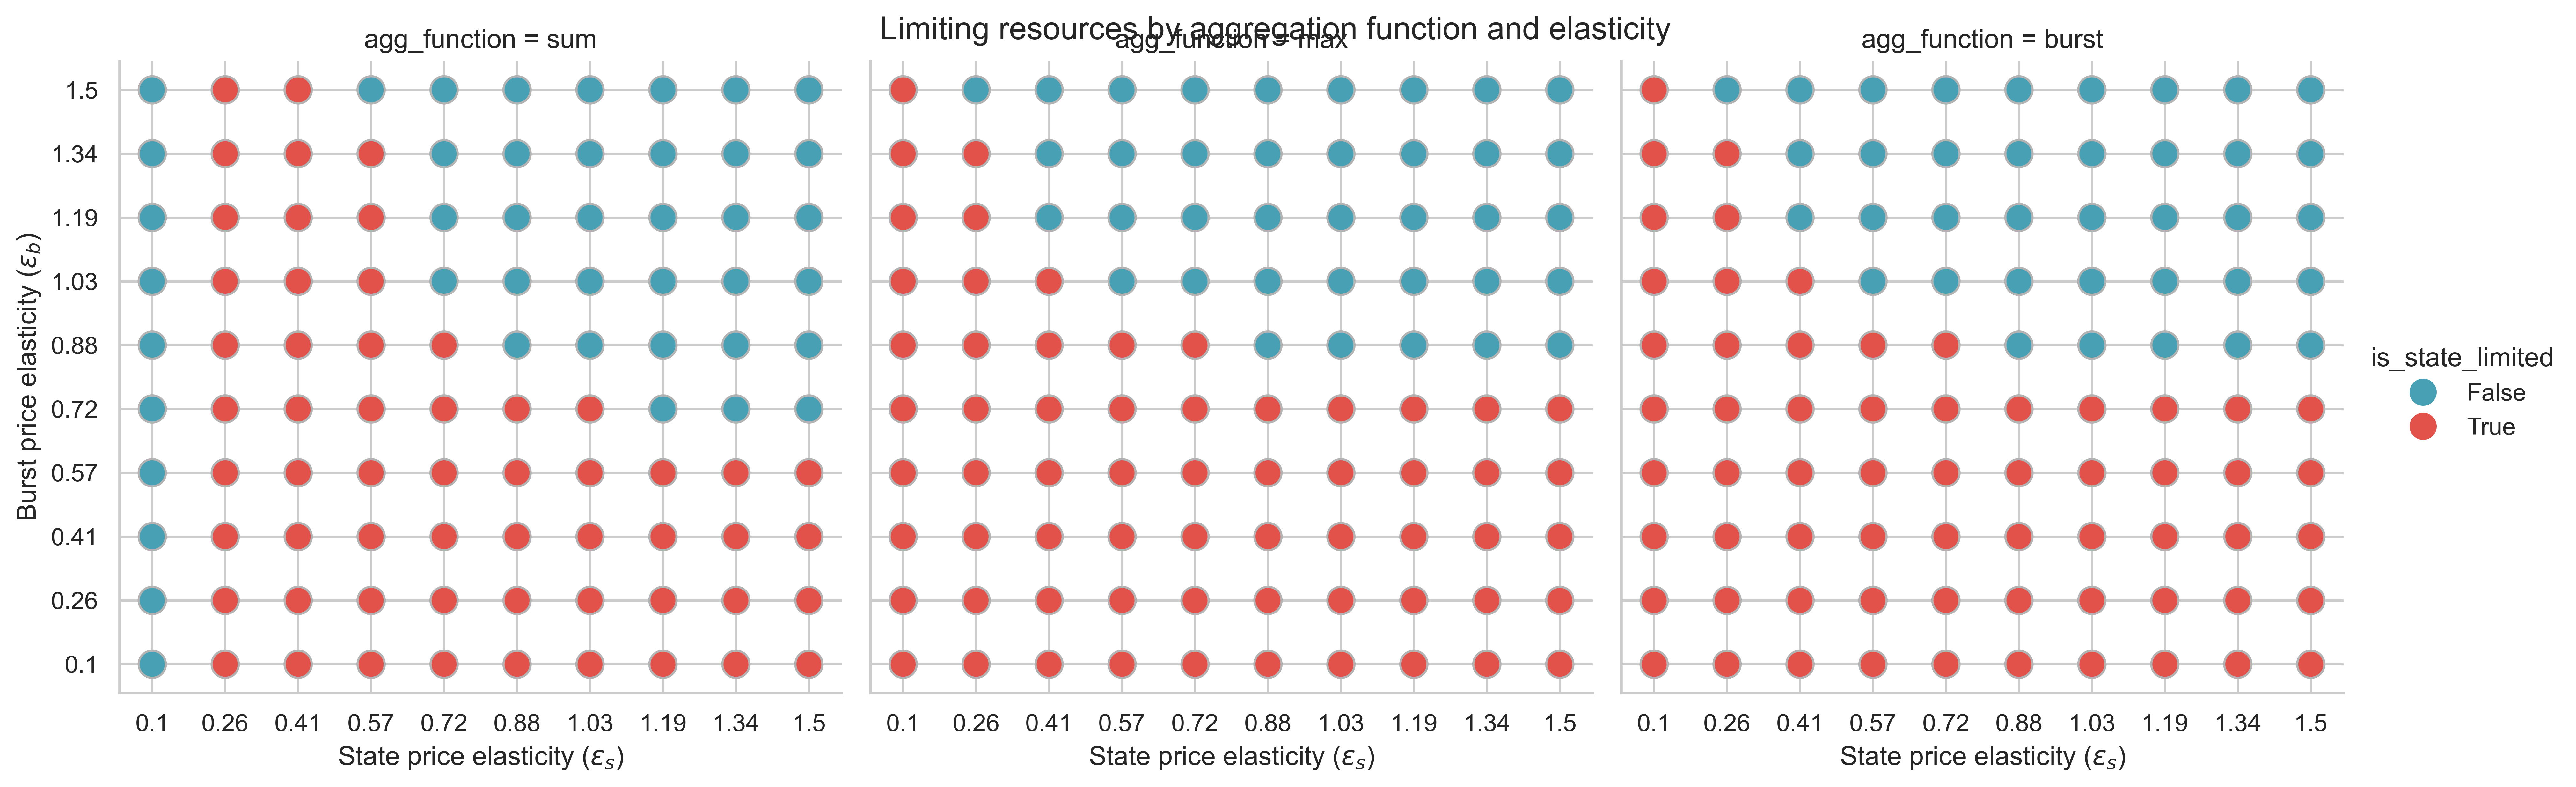

In [116]:
g = sns.relplot(
    data=results_df,
    x="eps_s",
    y="eps_b",
    hue="is_state_limited",
    col="agg_function",
    palette="Spectral_r",
    hue_norm=(-0.2, 1.2),
    edgecolor=".7",
    s=150,
)
g.set(
    xlabel=r"State price elasticity ($\varepsilon_s$)",
    ylabel=r"Burst price elasticity ($\varepsilon_b$)",
)
for ax in g.axes[0]:
    ax.invert_yaxis()
plt.suptitle("Limiting resources by aggregation function and elasticity")
our_file = os.path.join(our_dir, f"limiting_resource_m={m}.png")
plt.savefig(our_file, bbox_inches="tight")
plt.show()

### Impact on state growth

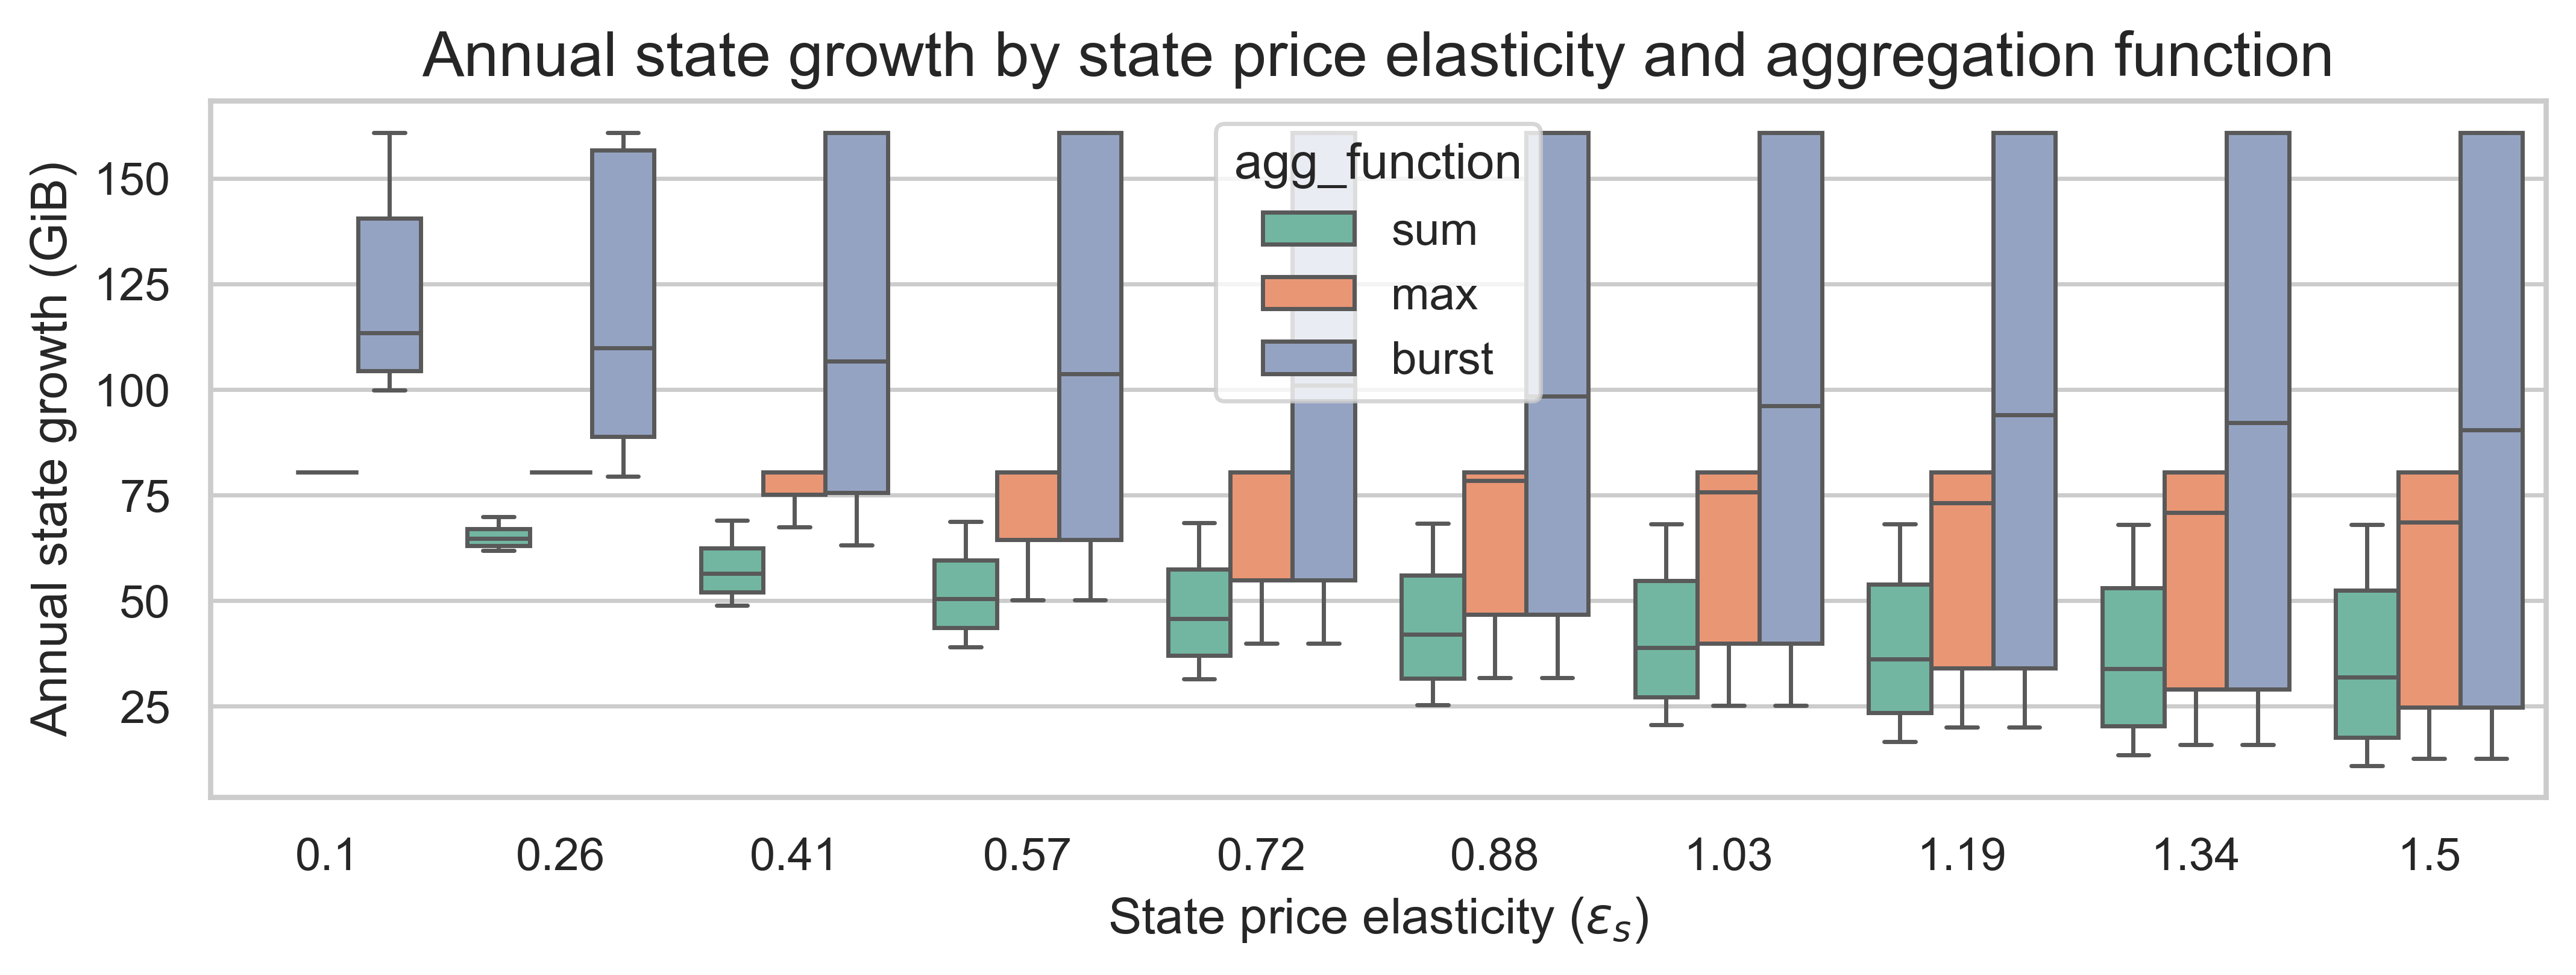

In [117]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df,
    x="eps_s",
    y="annual_state_growth_gib",
    hue="agg_function",
    showfliers=False,
)

plt.title("Annual state growth by state price elasticity and aggregation function")
plt.ylabel("Annual state growth (GiB)")
plt.xlabel(r"State price elasticity ($\varepsilon_s$)")
our_file = os.path.join(our_dir, f"state_growth_by_eps_s_m={m}.png")
plt.savefig(our_file, bbox_inches="tight")
plt.show()

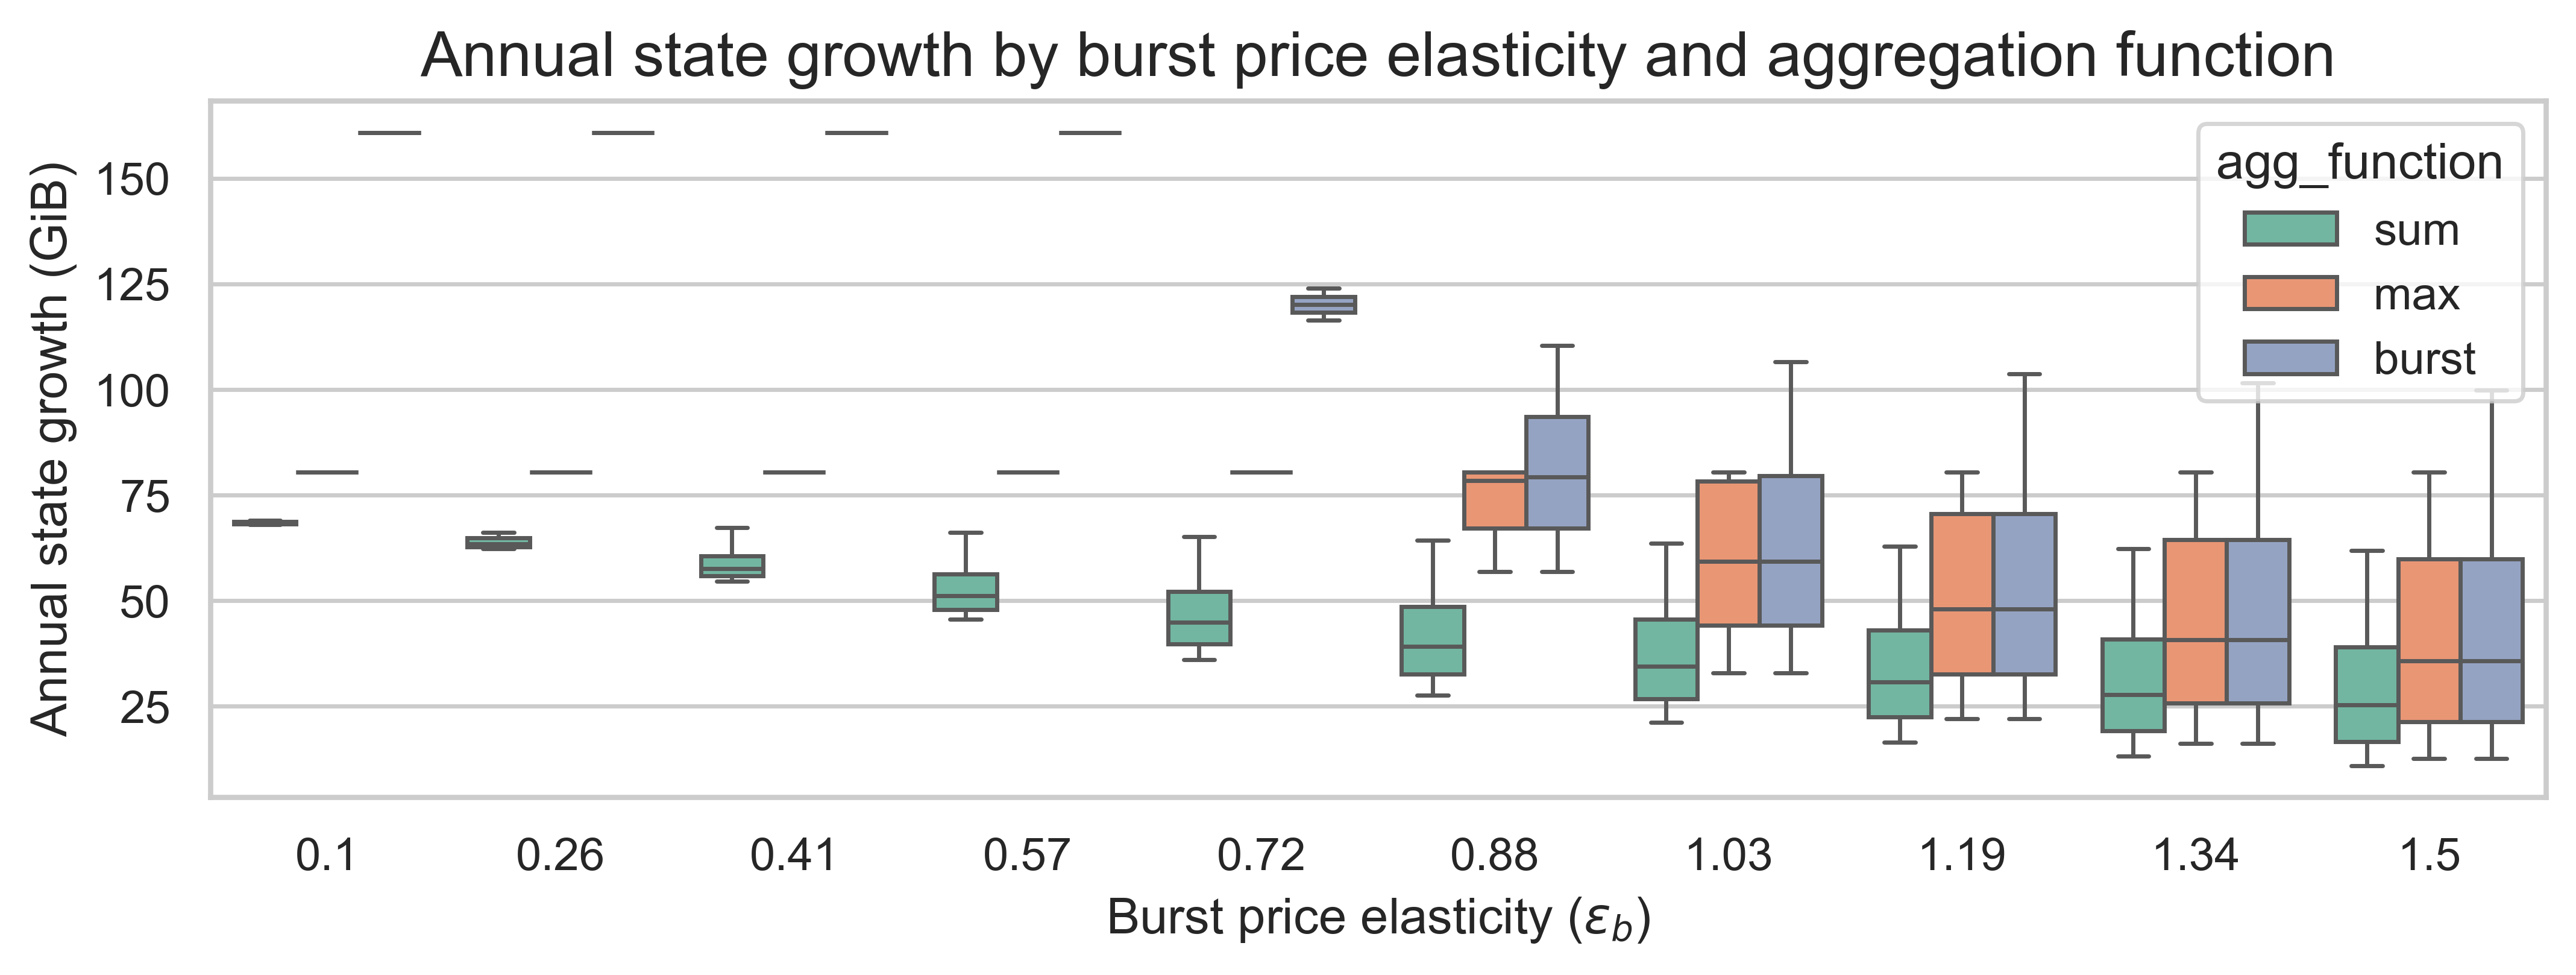

In [118]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df,
    x="eps_b",
    y="annual_state_growth_gib",
    hue="agg_function",
    showfliers=False,
)

plt.title("Annual state growth by burst price elasticity and aggregation function")
plt.ylabel("Annual state growth (GiB)")
plt.xlabel(r"Burst price elasticity ($\varepsilon_b$)")
our_file = os.path.join(our_dir, f"state_growth_by_eps_b_m={m}.png")
plt.savefig(our_file, bbox_inches="tight")
plt.show()

In [119]:
results_df.groupby("agg_function")["annual_state_growth_gib"].agg(
    ["min", "median", "max"]
)

,min,median,max
agg_function,,,
burst,12.641141,113.421825,160.895454
max,12.641141,80.447727,80.447727
sum,10.924518,49.102032,69.872181


### Impact on throughput gain

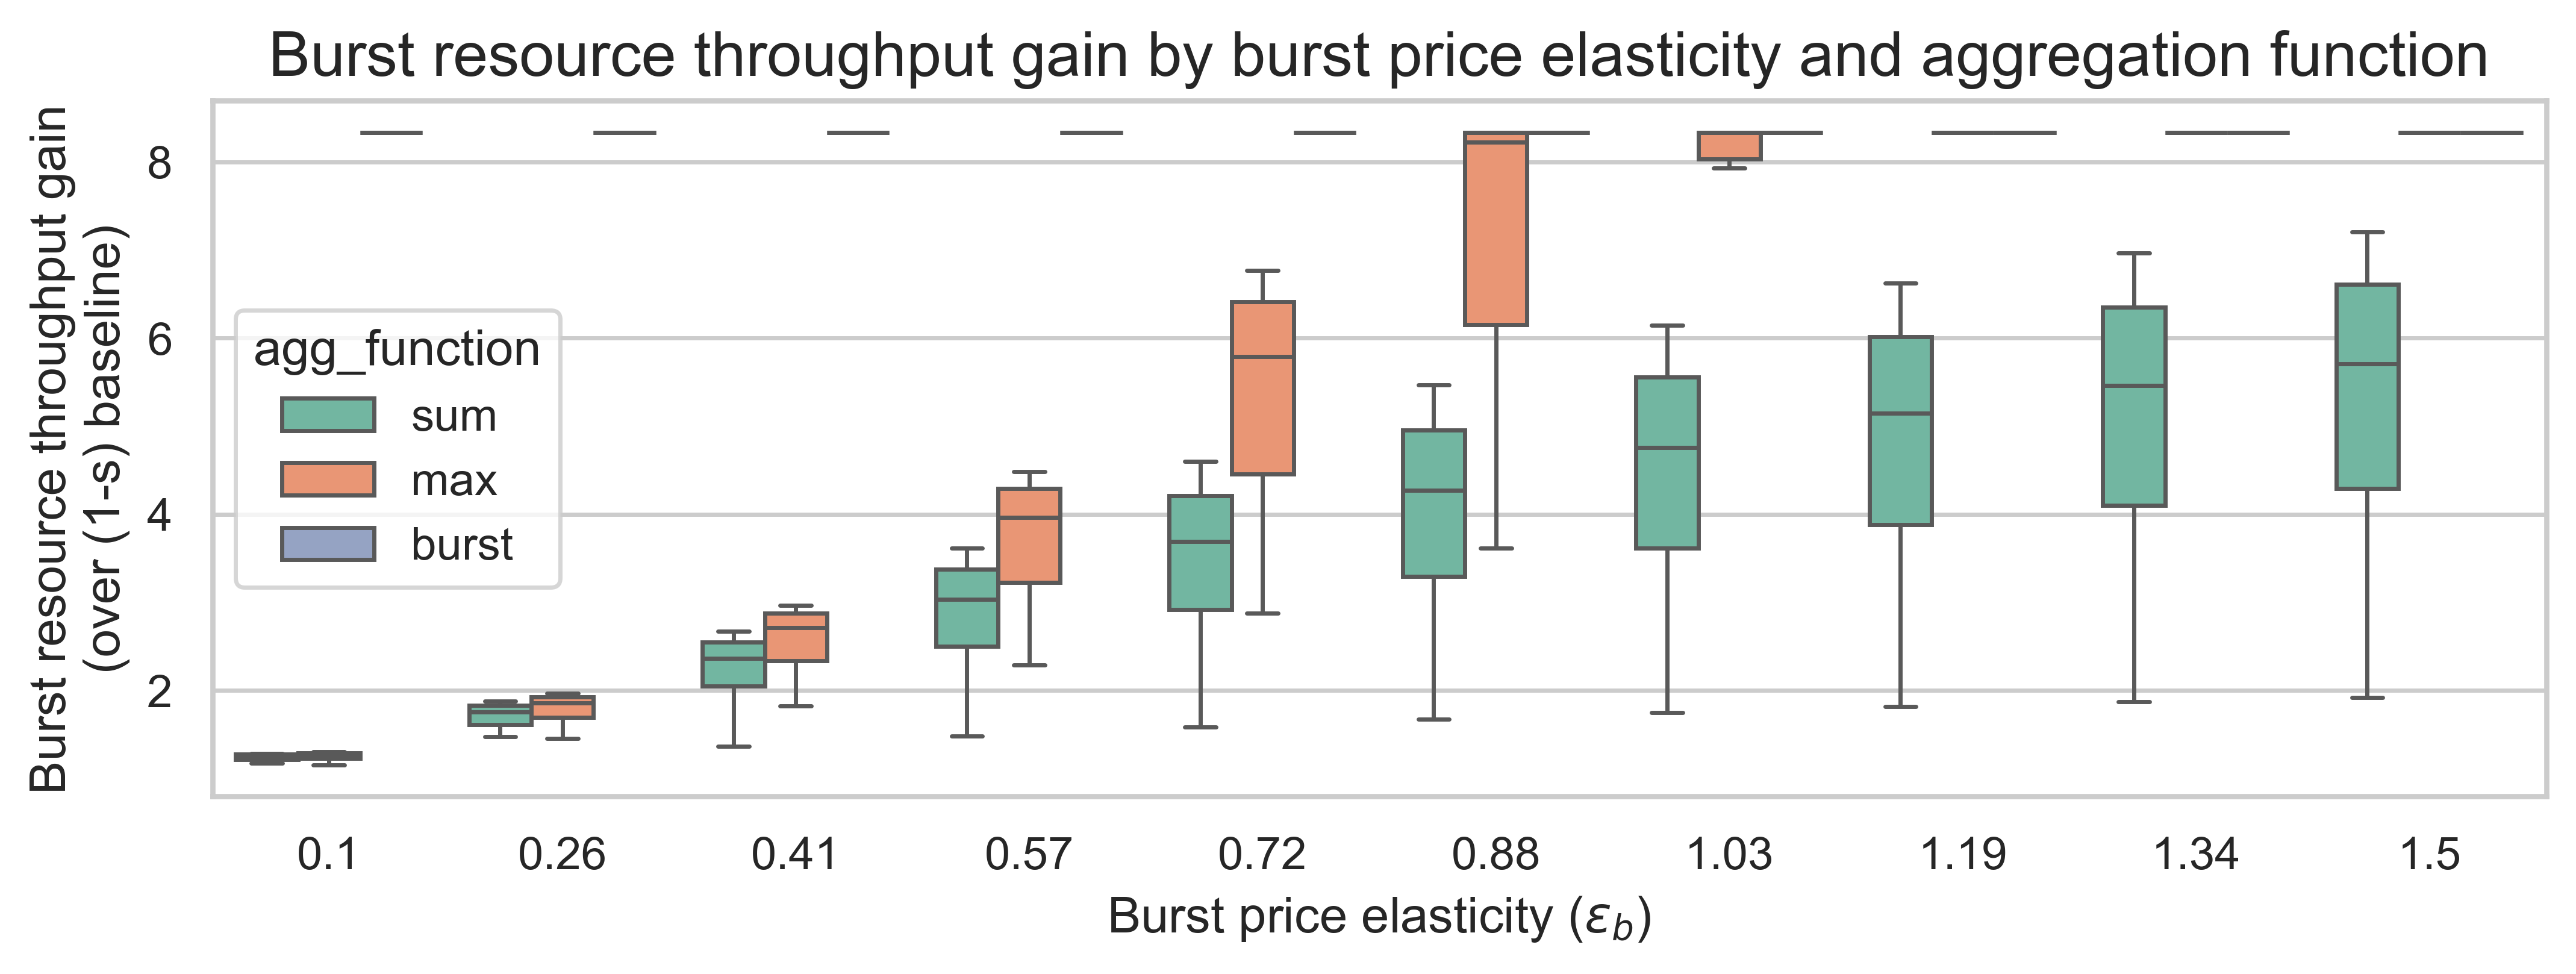

In [120]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df,
    x="eps_b",
    y="burst_throughput_gain",
    hue="agg_function",
    showfliers=False,
)

plt.title(
    "Burst resource throughput gain by burst price elasticity and aggregation function"
)
plt.ylabel("Burst resource throughput gain\n(over (1-s) baseline)")
plt.xlabel(r"Burst price elasticity ($\varepsilon_b$)")
our_file = os.path.join(our_dir, f"burst_throughput_by_eps_b_m={m}.png")
plt.savefig(our_file, bbox_inches="tight")
plt.show()

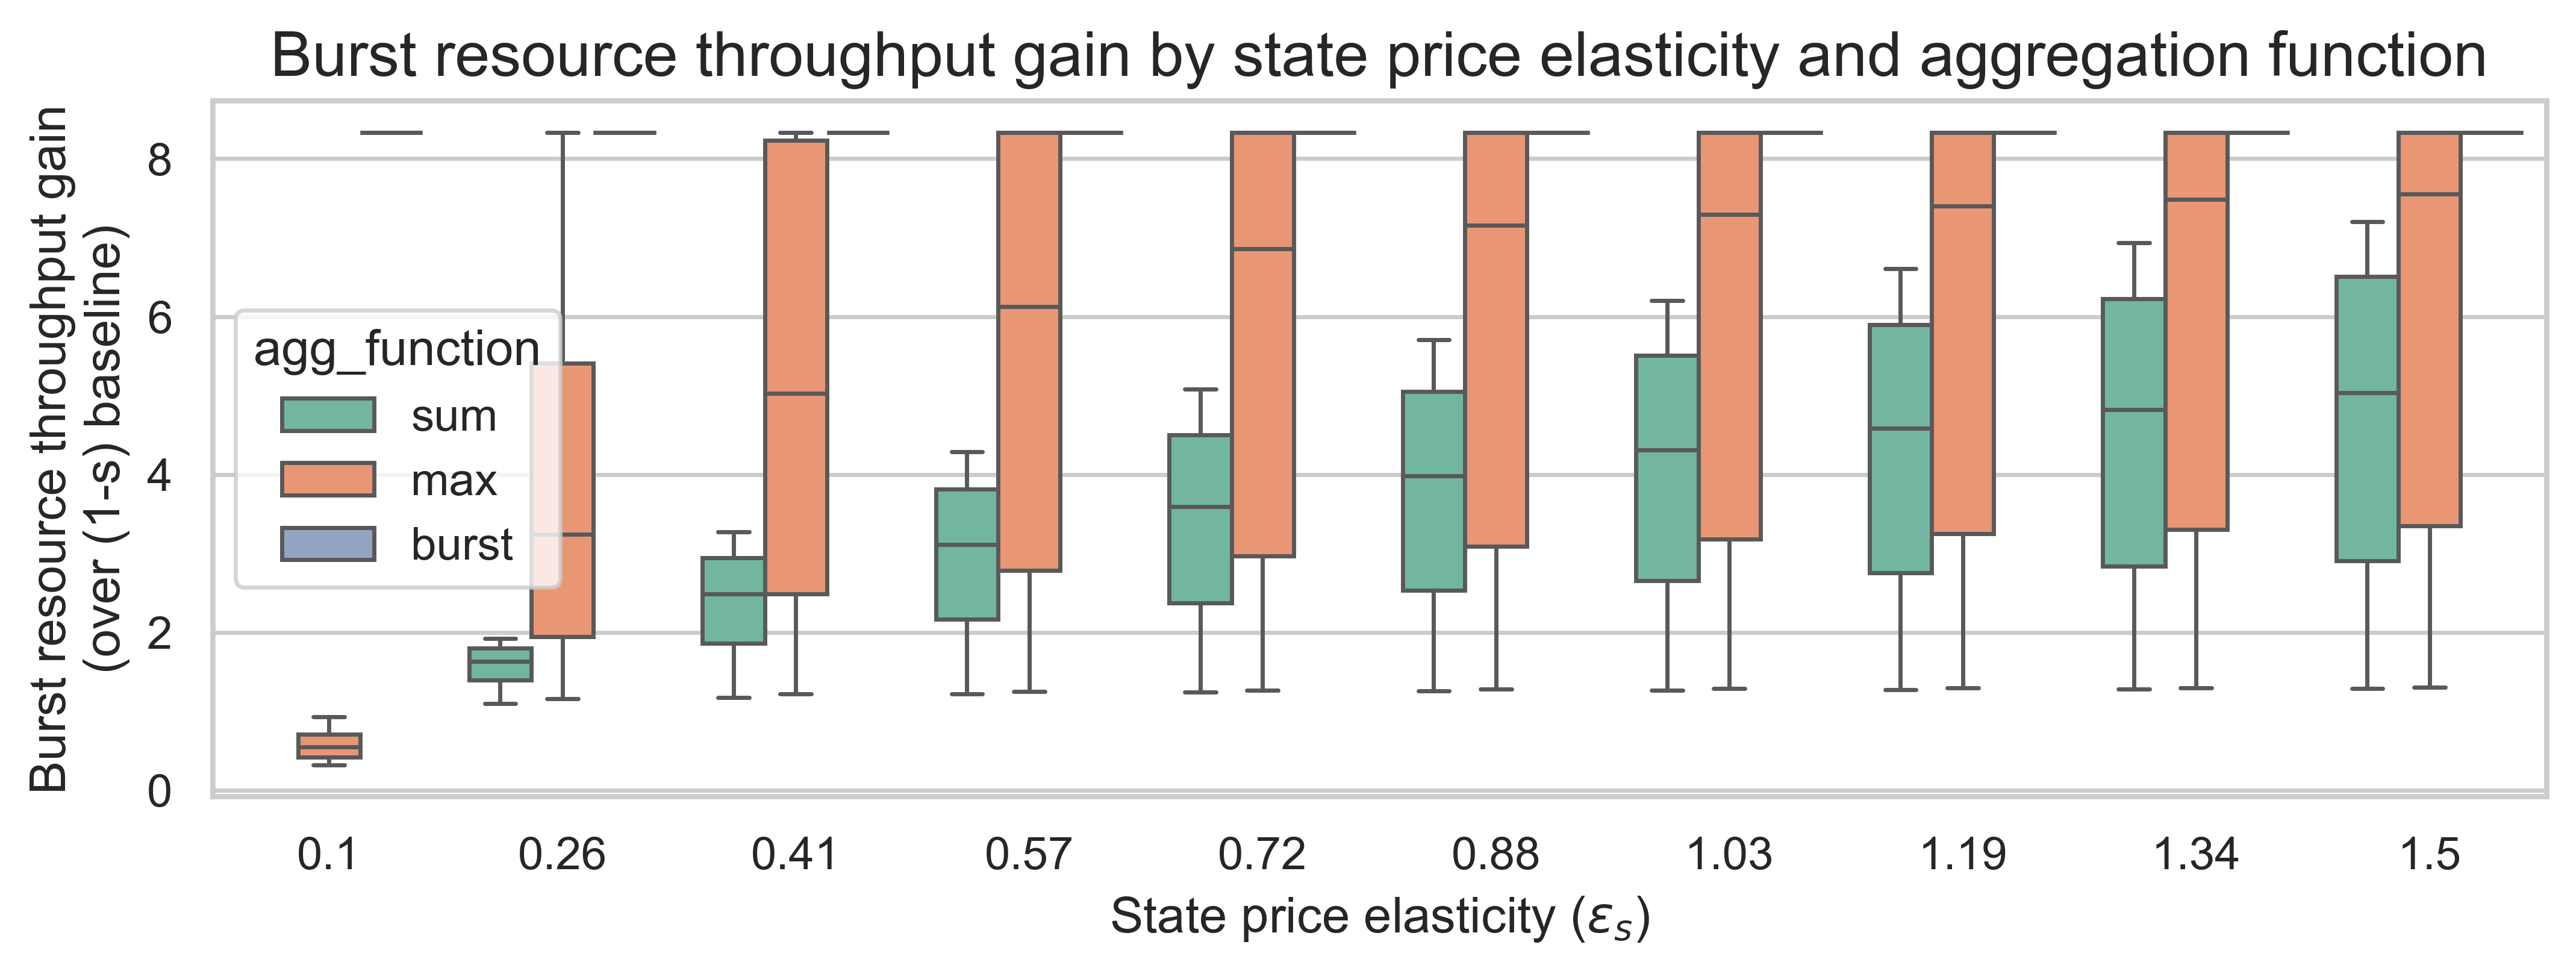

In [121]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df,
    x="eps_s",
    y="burst_throughput_gain",
    hue="agg_function",
    showfliers=False,
)

plt.title(
    "Burst resource throughput gain by state price elasticity and aggregation function"
)
plt.ylabel("Burst resource throughput gain\n(over (1-s) baseline)")
plt.xlabel(r"State price elasticity ($\varepsilon_s$)")
our_file = os.path.join(our_dir, f"burst_throughput_by_eps_s_m={m}.png")
plt.savefig(our_file, bbox_inches="tight")
plt.show()

In [122]:
results_df.groupby("agg_function")["burst_throughput_gain"].agg(
    ["min", "median", "max"]
)

,min,median,max
agg_function,,,
burst,8.333333,8.333333,8.333333
max,0.321715,4.802058,8.333333
sum,1.095488,3.247004,7.201696


In [123]:
temp_df = results_df.copy()
temp_df["high_gain"] = results_df["burst_throughput_gain"]>=5.0
temp_df.groupby("agg_function")["high_gain"].mean()

agg_function
burst    1.00
max      0.50
sum      0.22
Name: high_gain, dtype: float64

In [124]:
temp_df = results_df.copy()
temp_df["high_gain"] = results_df["burst_throughput_gain"]>=5.0
temp_df.groupby("limiting_resource")["high_gain"].mean()

limiting_resource
burst    0.897196
state    0.415301
Name: high_gain, dtype: float64

### Impact on base fee

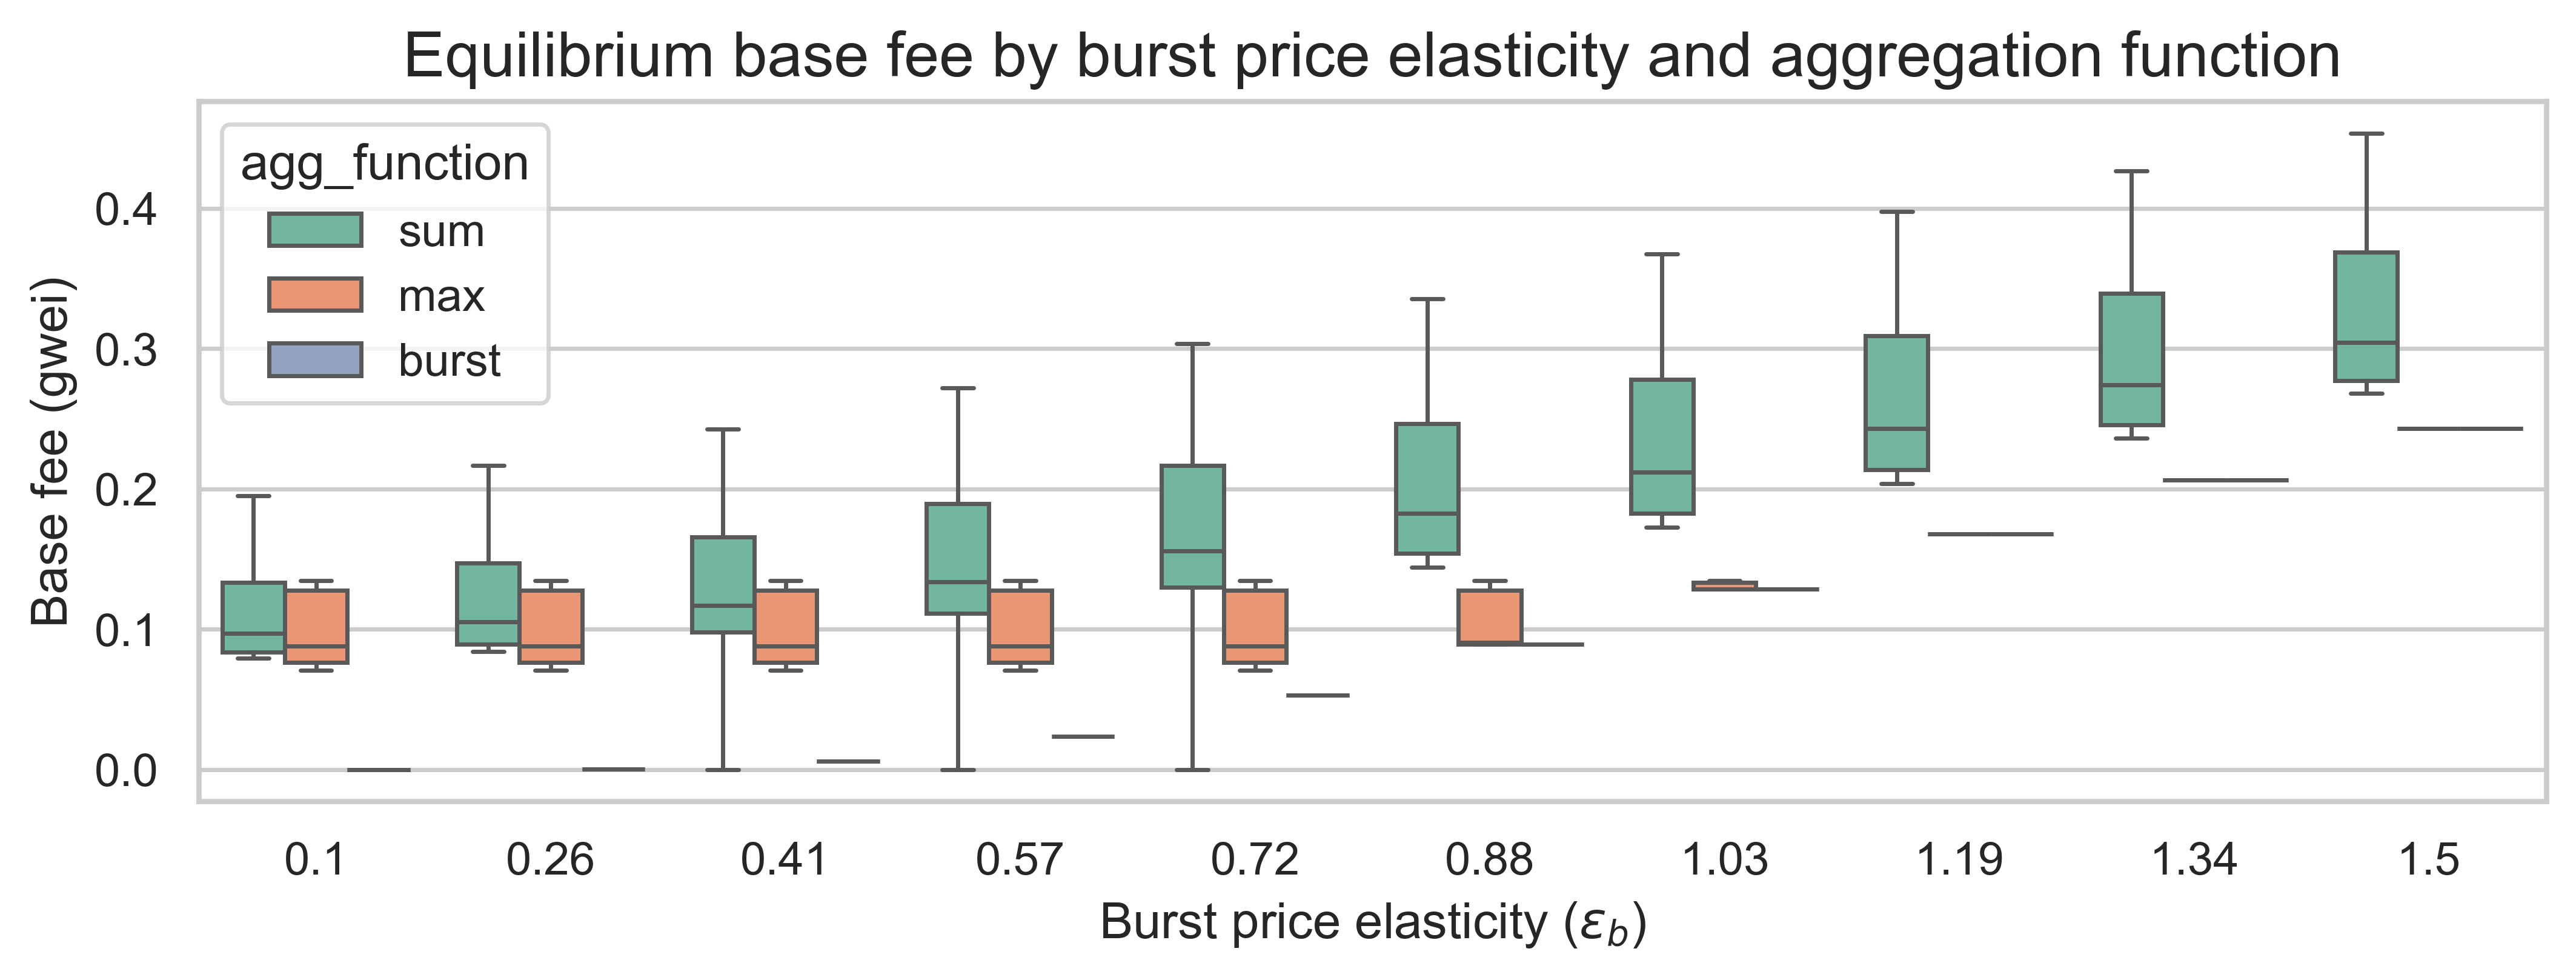

In [125]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df, x="eps_b", y="b_star", hue="agg_function", showfliers=False
)

plt.title("Equilibrium base fee by burst price elasticity and aggregation function")
plt.ylabel("Base fee (gwei)")
plt.xlabel(r"Burst price elasticity ($\varepsilon_b$)")
plt.show()

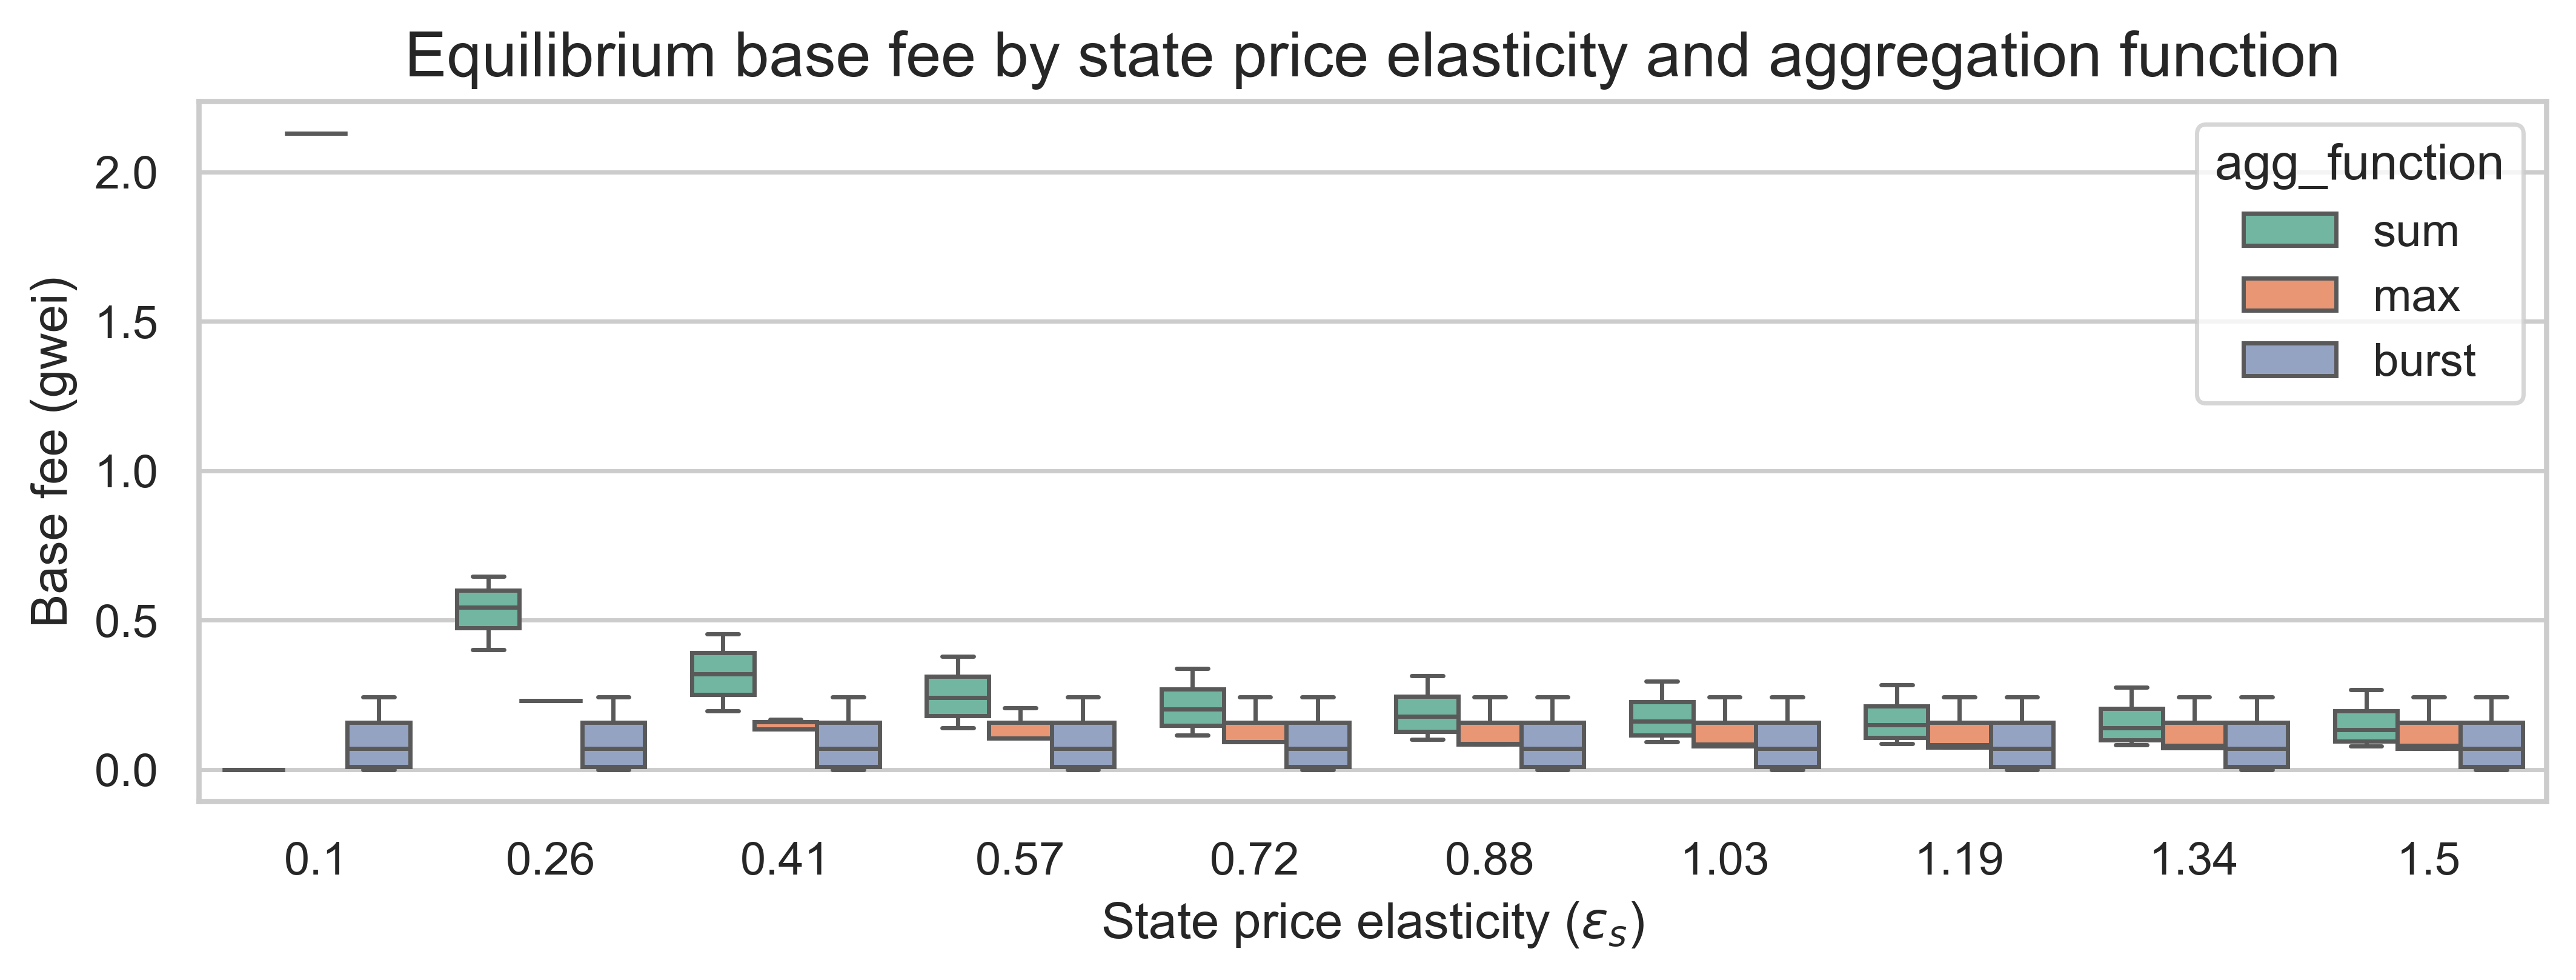

In [126]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df, x="eps_s", y="b_star", hue="agg_function", showfliers=False
)

plt.title("Equilibrium base fee by state price elasticity and aggregation function")
plt.ylabel("Base fee (gwei)")
plt.xlabel(r"State price elasticity ($\varepsilon_s$)")
plt.show()

### Impact on burst share

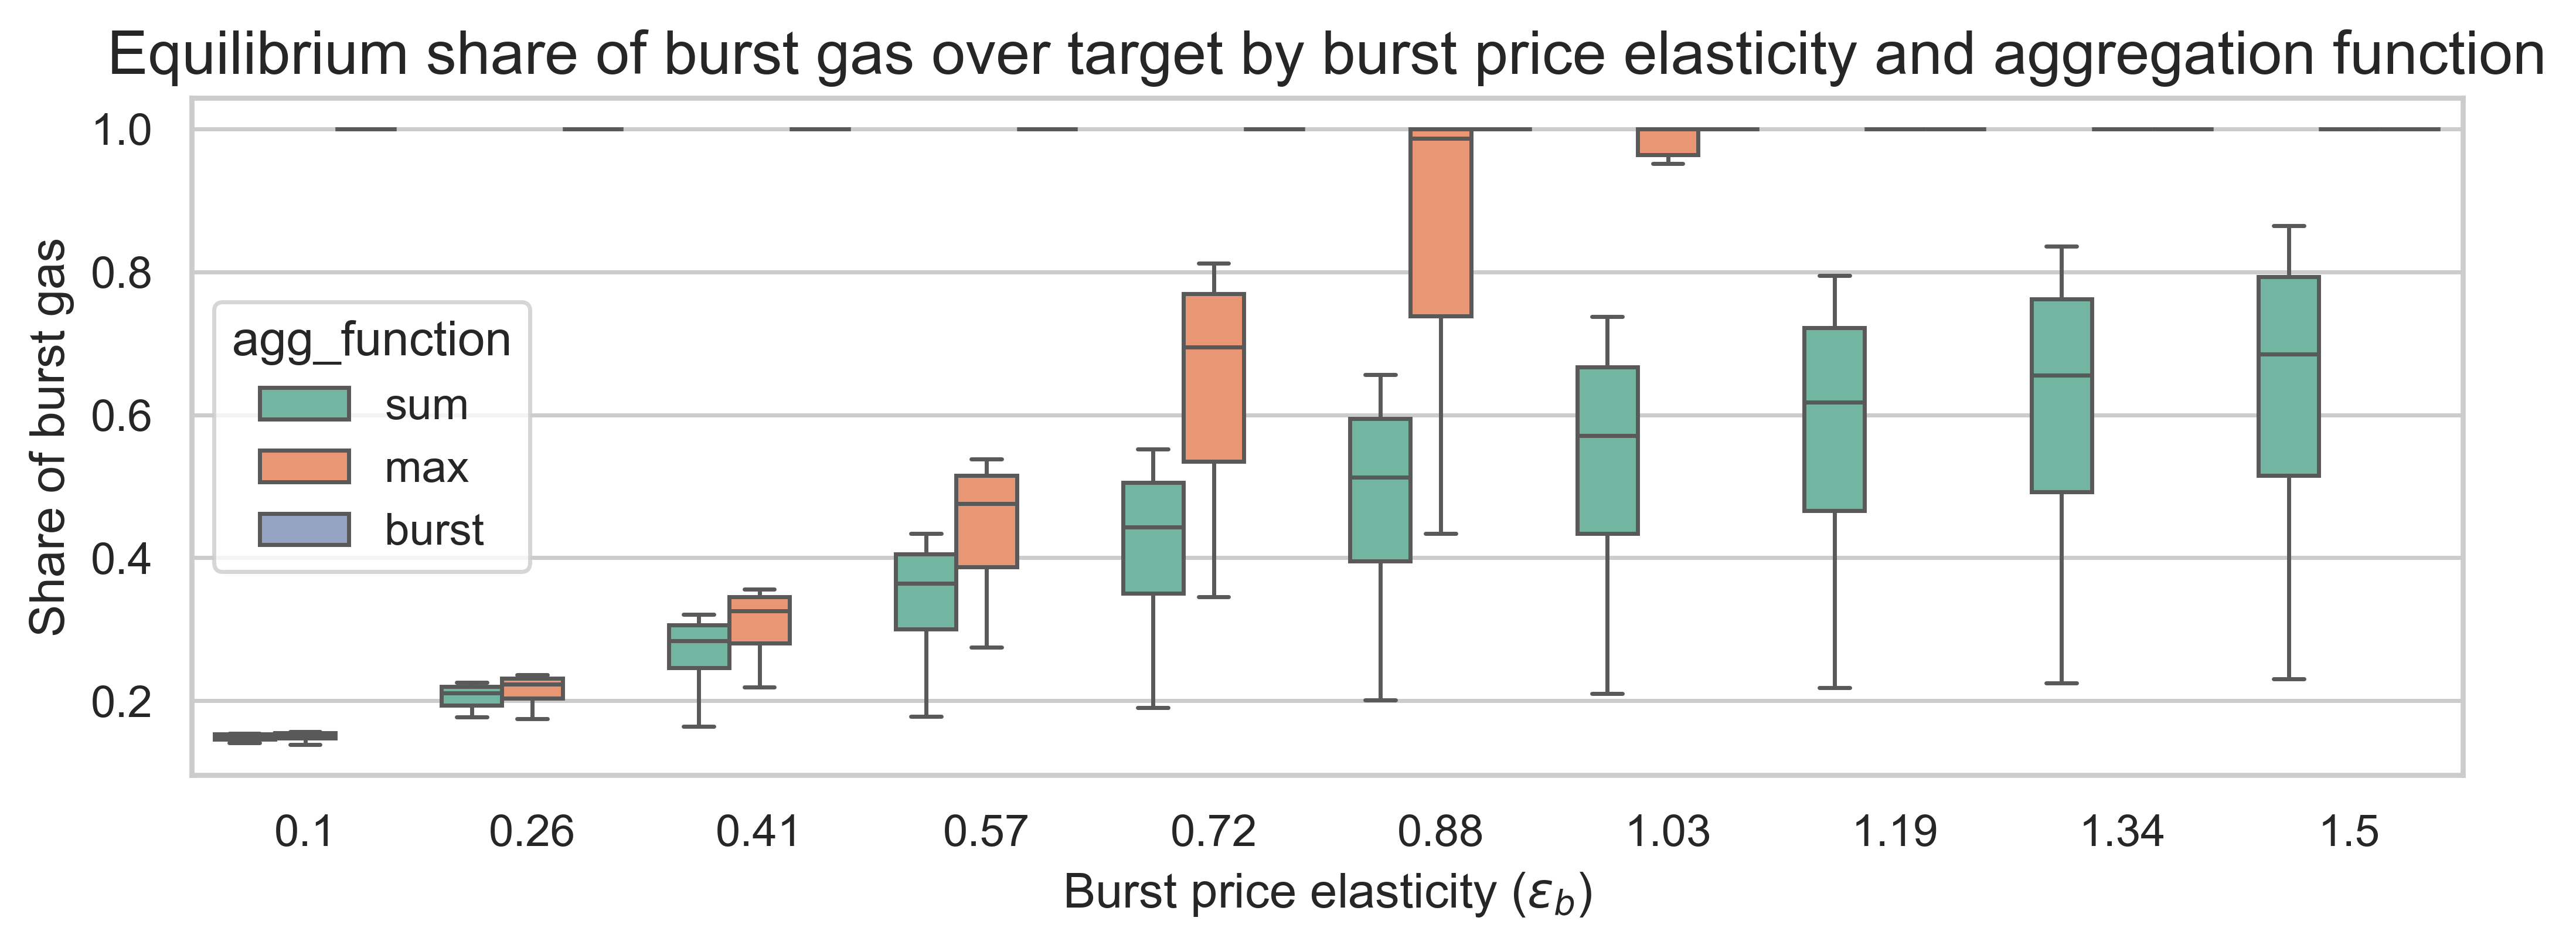

In [127]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df, x="eps_b", y="share_burst", hue="agg_function", showfliers=False
)

plt.title(
    "Equilibrium share of burst gas over target by burst price elasticity and aggregation function"
)
plt.ylabel("Share of burst gas")
plt.xlabel(r"Burst price elasticity ($\varepsilon_b$)")
plt.show()

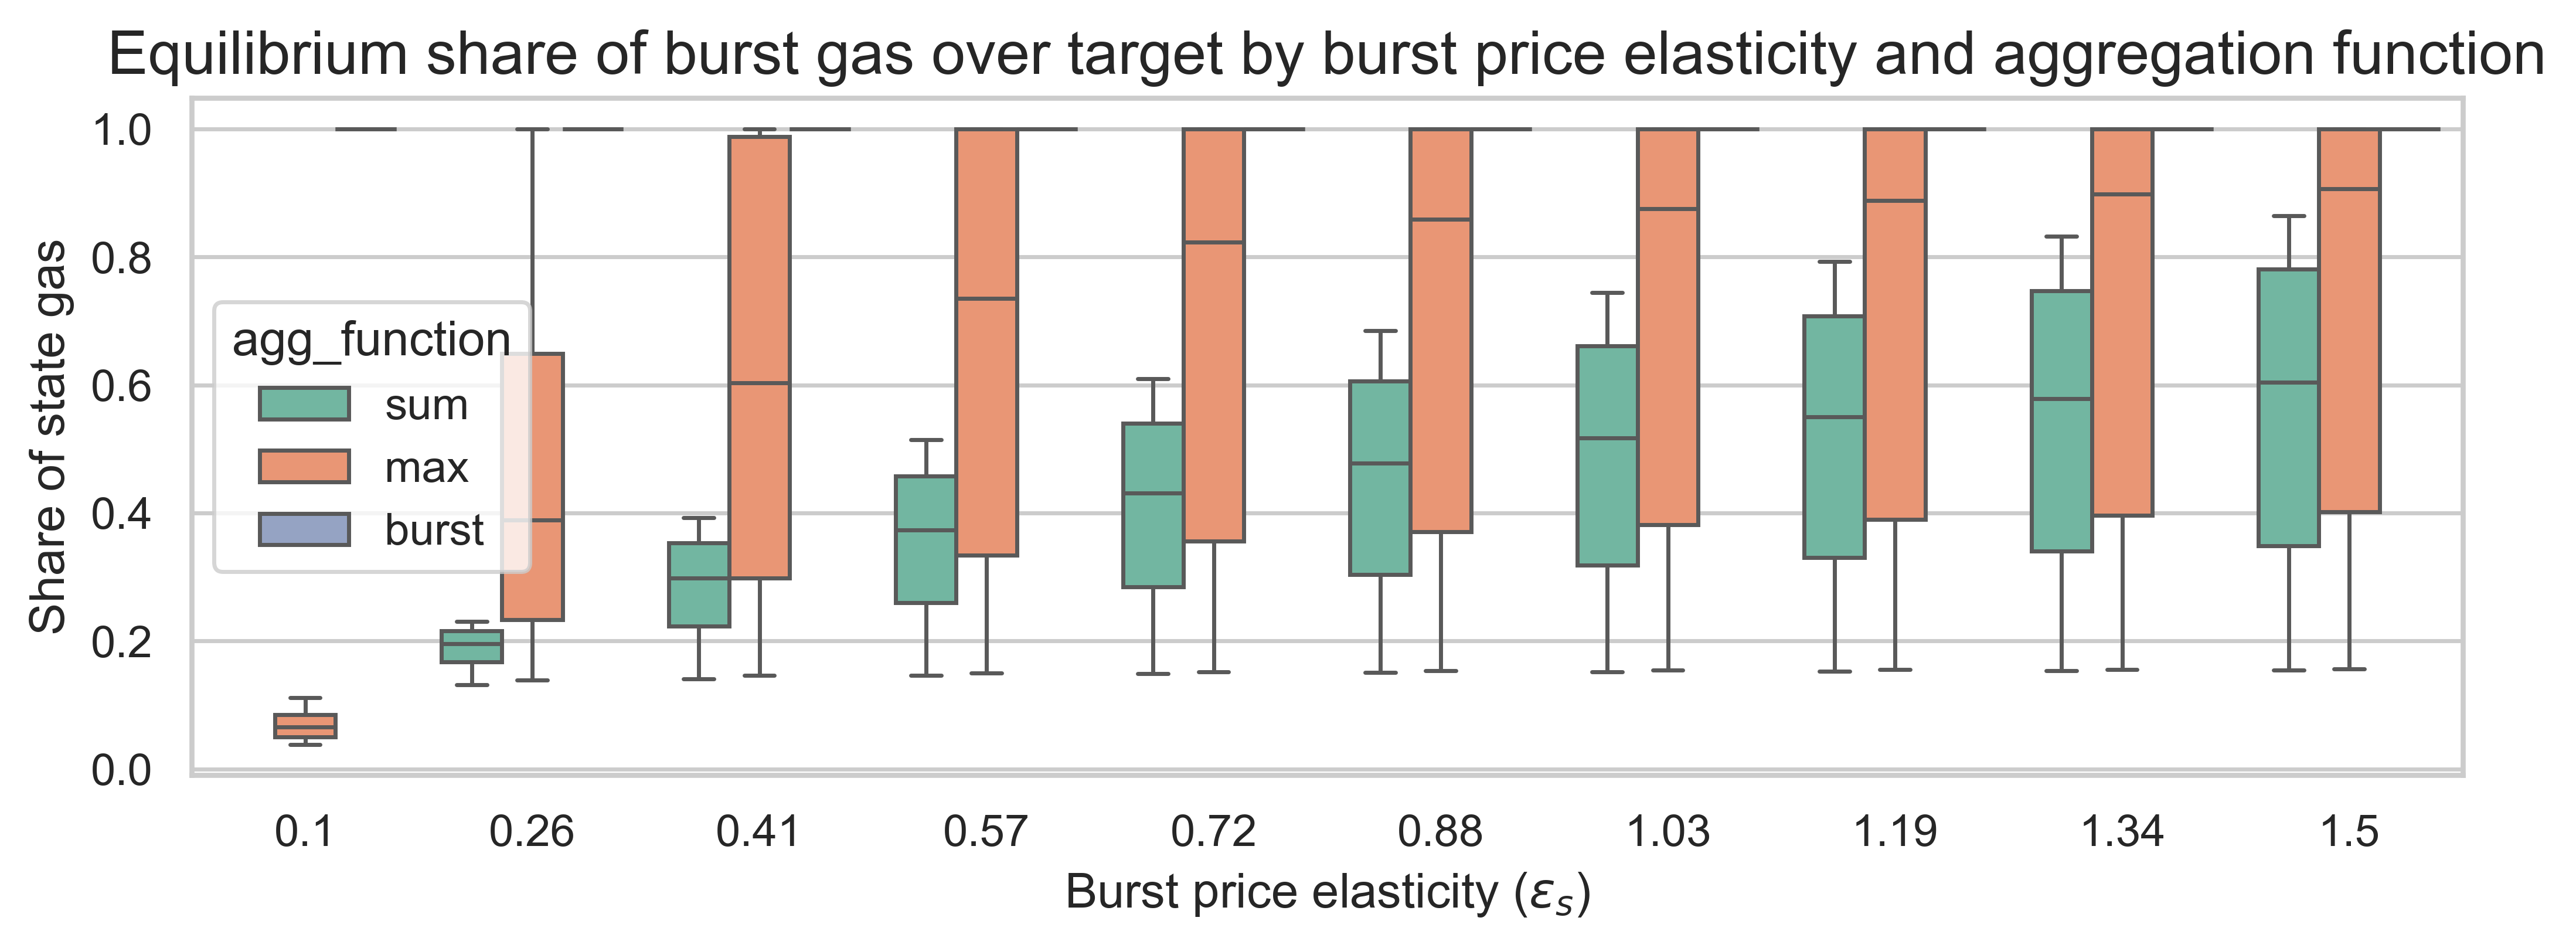

In [128]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df, x="eps_s", y="share_burst", hue="agg_function", showfliers=False
)

plt.title(
    "Equilibrium share of burst gas over target by burst price elasticity and aggregation function"
)
plt.ylabel("Share of state gas")
plt.xlabel(r"Burst price elasticity ($\varepsilon_s$)")
plt.show()

## Repricing impact for 5x gas limit and 10x price increase

#### Parameters

- $n=5$
- $m=10$
- $s=0.4$
- $G^0=60$ (in million gas units)
- $b^0=1$ (in gwei)
- State growth is 325 MiB per day $\implies$ $S^0 = \frac{325 \cdot 1048576 \cdot 12}{60 \cdot 60 \cdot 24}$ bytes
- $\varepsilon_s,\varepsilon_b  \in [0.1, 1.5]$



In [129]:
n = 5
m = 10
s = 0.4
G_0 = 60
b_0 = 1.0
S_0 = (325 * 1048576 * 12) / (60 * 60 * 24)
results_list = []

for eps_s in np.linspace(0.1, 1.5, 10):
    for eps_b in np.linspace(0.1, 1.5, 10):
        # Find equilibrium for sum function
        b_star_sum = state_growth.find_equilibrium_base_fee_sum(
            m, n, eps_s, eps_b, b_0, s
        )
        # Compute usage and shares for sum function
        results = state_growth.compute_equilibrium_stats(
            b_star_sum, m, n, eps_s, eps_b, G_0, b_0, S_0, s
        )
        results["eps_s"] = eps_s.round(2).astype(str)
        results["eps_b"] = eps_b.round(2).astype(str)
        results["agg_function"] = "sum"
        results_list.append(results)
        # Find equilibrium for max function
        b_star_max = state_growth.find_equilibrium_base_fee_max(
            m, n, eps_s, eps_b, b_0, s
        )
        # Compute usage and shares for max function
        results = state_growth.compute_equilibrium_stats(
            b_star_max, m, n, eps_s, eps_b, G_0, b_0, S_0, s
        )
        results["eps_s"] = eps_s.round(2).astype(str)
        results["eps_b"] = eps_b.round(2).astype(str)
        results["agg_function"] = "max"
        results_list.append(results)
        # Find equilibrium for burst function
        b_star_burst = state_growth.find_equilibrium_base_fee_burst(
            m, n, eps_s, eps_b, b_0, s
        )
        # Compute usage and shares for burst function
        results = state_growth.compute_equilibrium_stats(
            b_star_burst, m, n, eps_s, eps_b, G_0, b_0, S_0, s
        )
        results["eps_s"] = eps_s.round(2).astype(str)
        results["eps_b"] = eps_b.round(2).astype(str)
        results["agg_function"] = "burst"
        results_list.append(results)

results_df = pd.DataFrame(results_list)
results_df["burst_throughput_gain"] = results_df["burst_throughput_s"] / (1 - s)
results_df["is_state_limited"] = results_df["limiting_resource"] == "state"

### Limiting resource

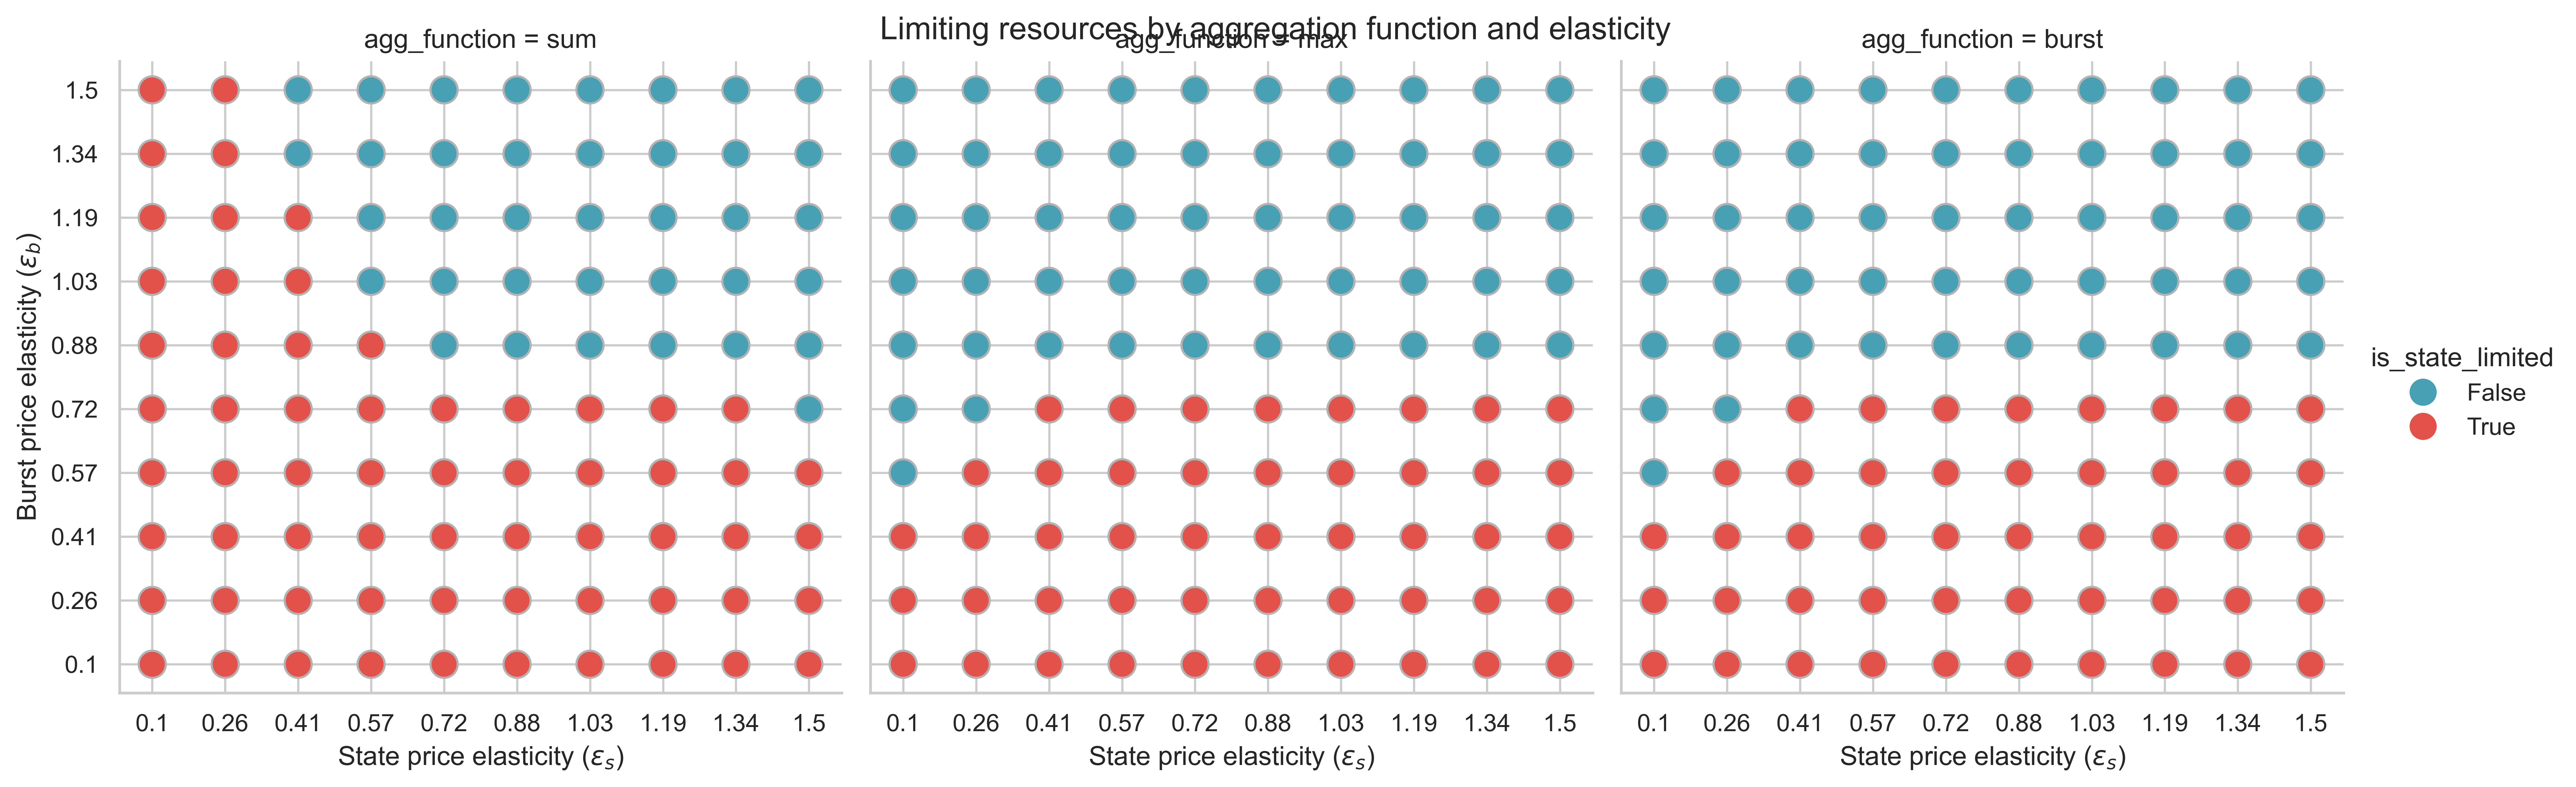

In [130]:
g = sns.relplot(
    data=results_df,
    x="eps_s",
    y="eps_b",
    hue="is_state_limited",
    col="agg_function",
    palette="Spectral_r",
    hue_norm=(-0.2, 1.2),
    edgecolor=".7",
    s=150,
)
g.set(
    xlabel=r"State price elasticity ($\varepsilon_s$)",
    ylabel=r"Burst price elasticity ($\varepsilon_b$)",
)
for ax in g.axes[0]:
    ax.invert_yaxis()
plt.suptitle("Limiting resources by aggregation function and elasticity")
our_file = os.path.join(our_dir, f"limiting_resource_m={m}.png")
plt.savefig(our_file, bbox_inches="tight")
plt.show()

### Impact on state growth

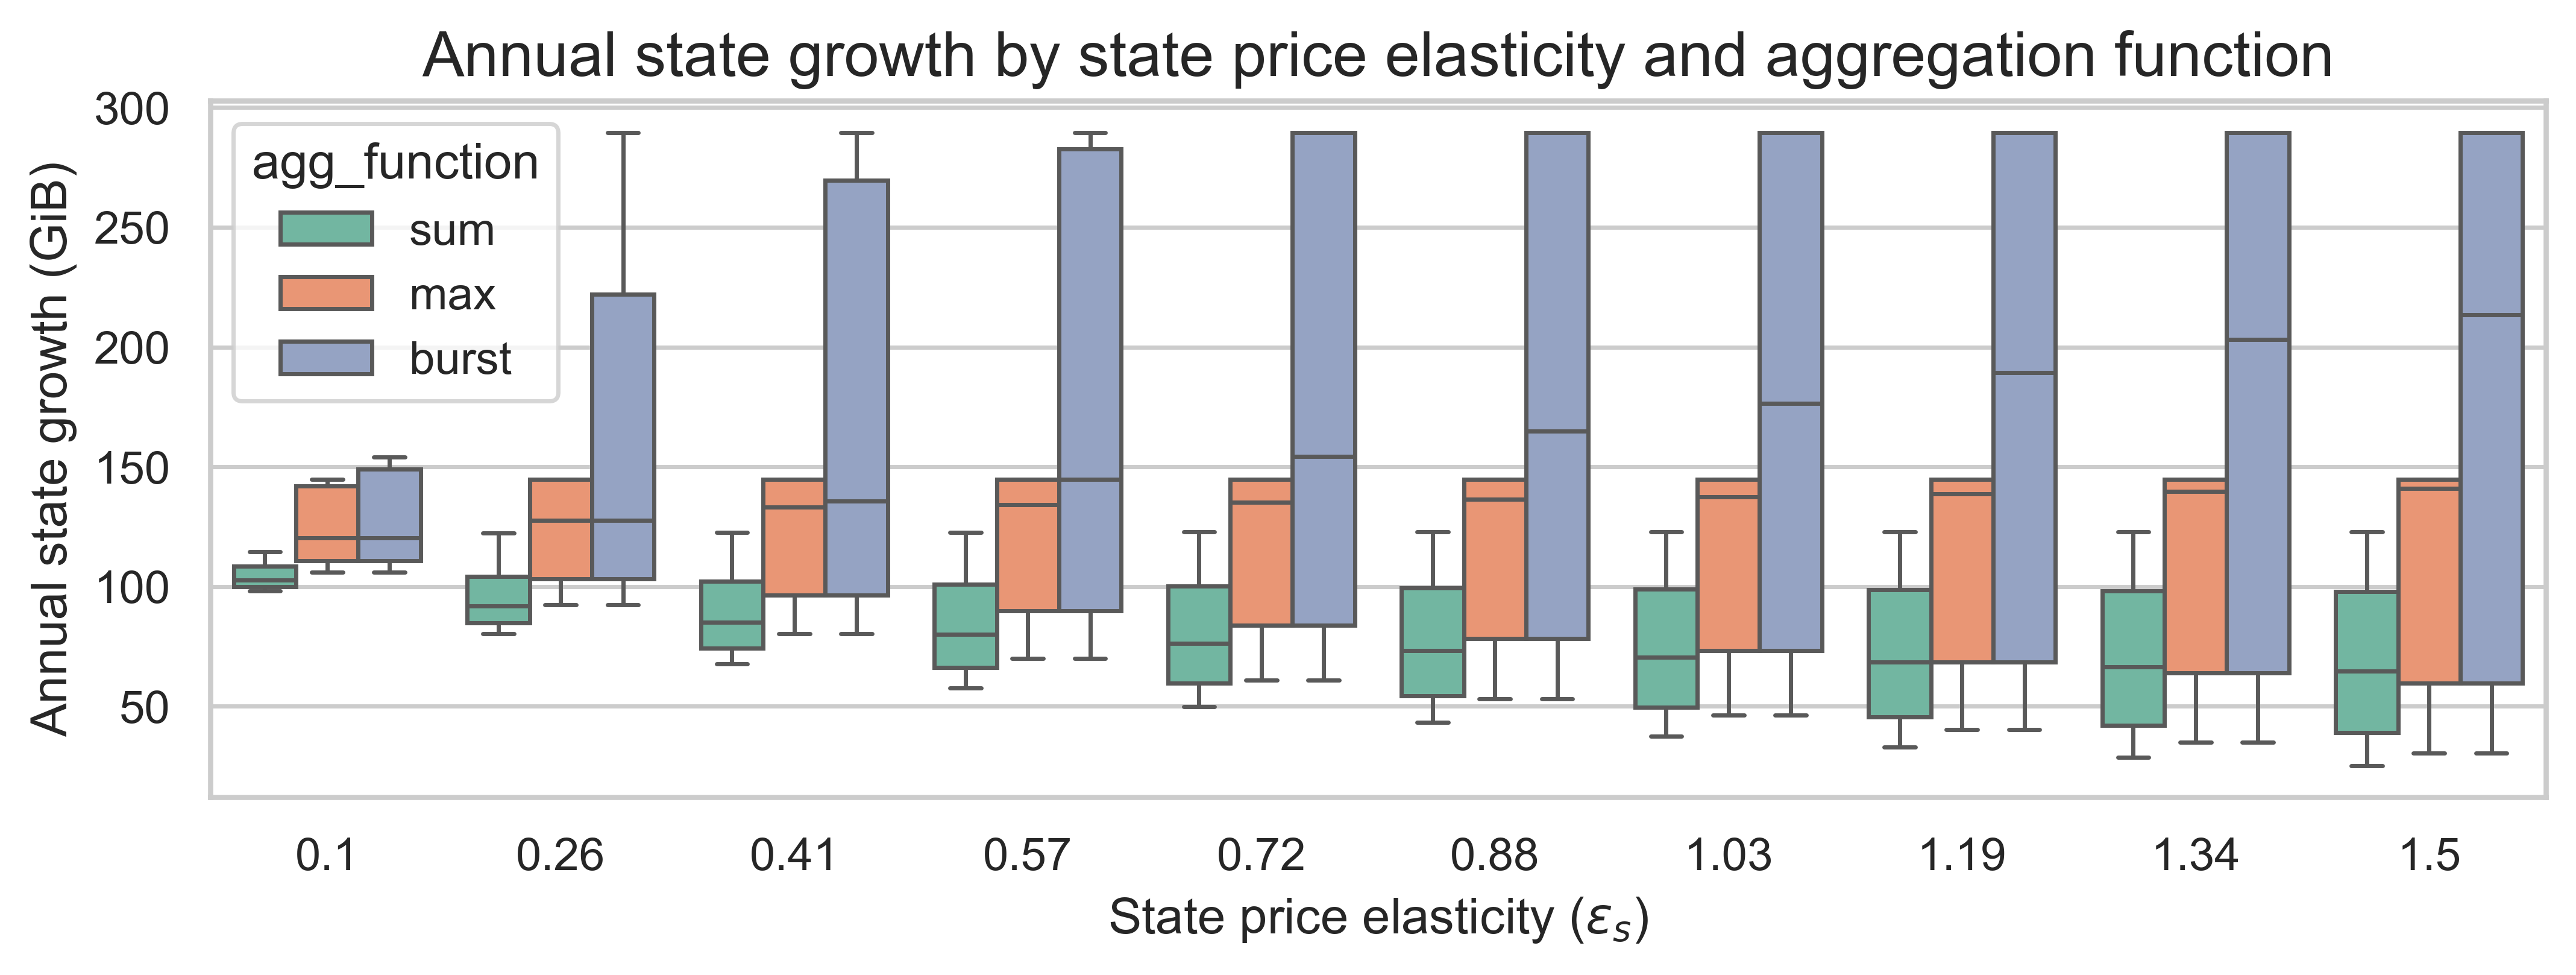

In [131]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df,
    x="eps_s",
    y="annual_state_growth_gib",
    hue="agg_function",
    showfliers=False,
)

plt.title("Annual state growth by state price elasticity and aggregation function")
plt.ylabel("Annual state growth (GiB)")
plt.xlabel(r"State price elasticity ($\varepsilon_s$)")
our_file = os.path.join(our_dir, f"state_growth_by_eps_s_m={m}.png")
plt.savefig(our_file, bbox_inches="tight")
plt.show()

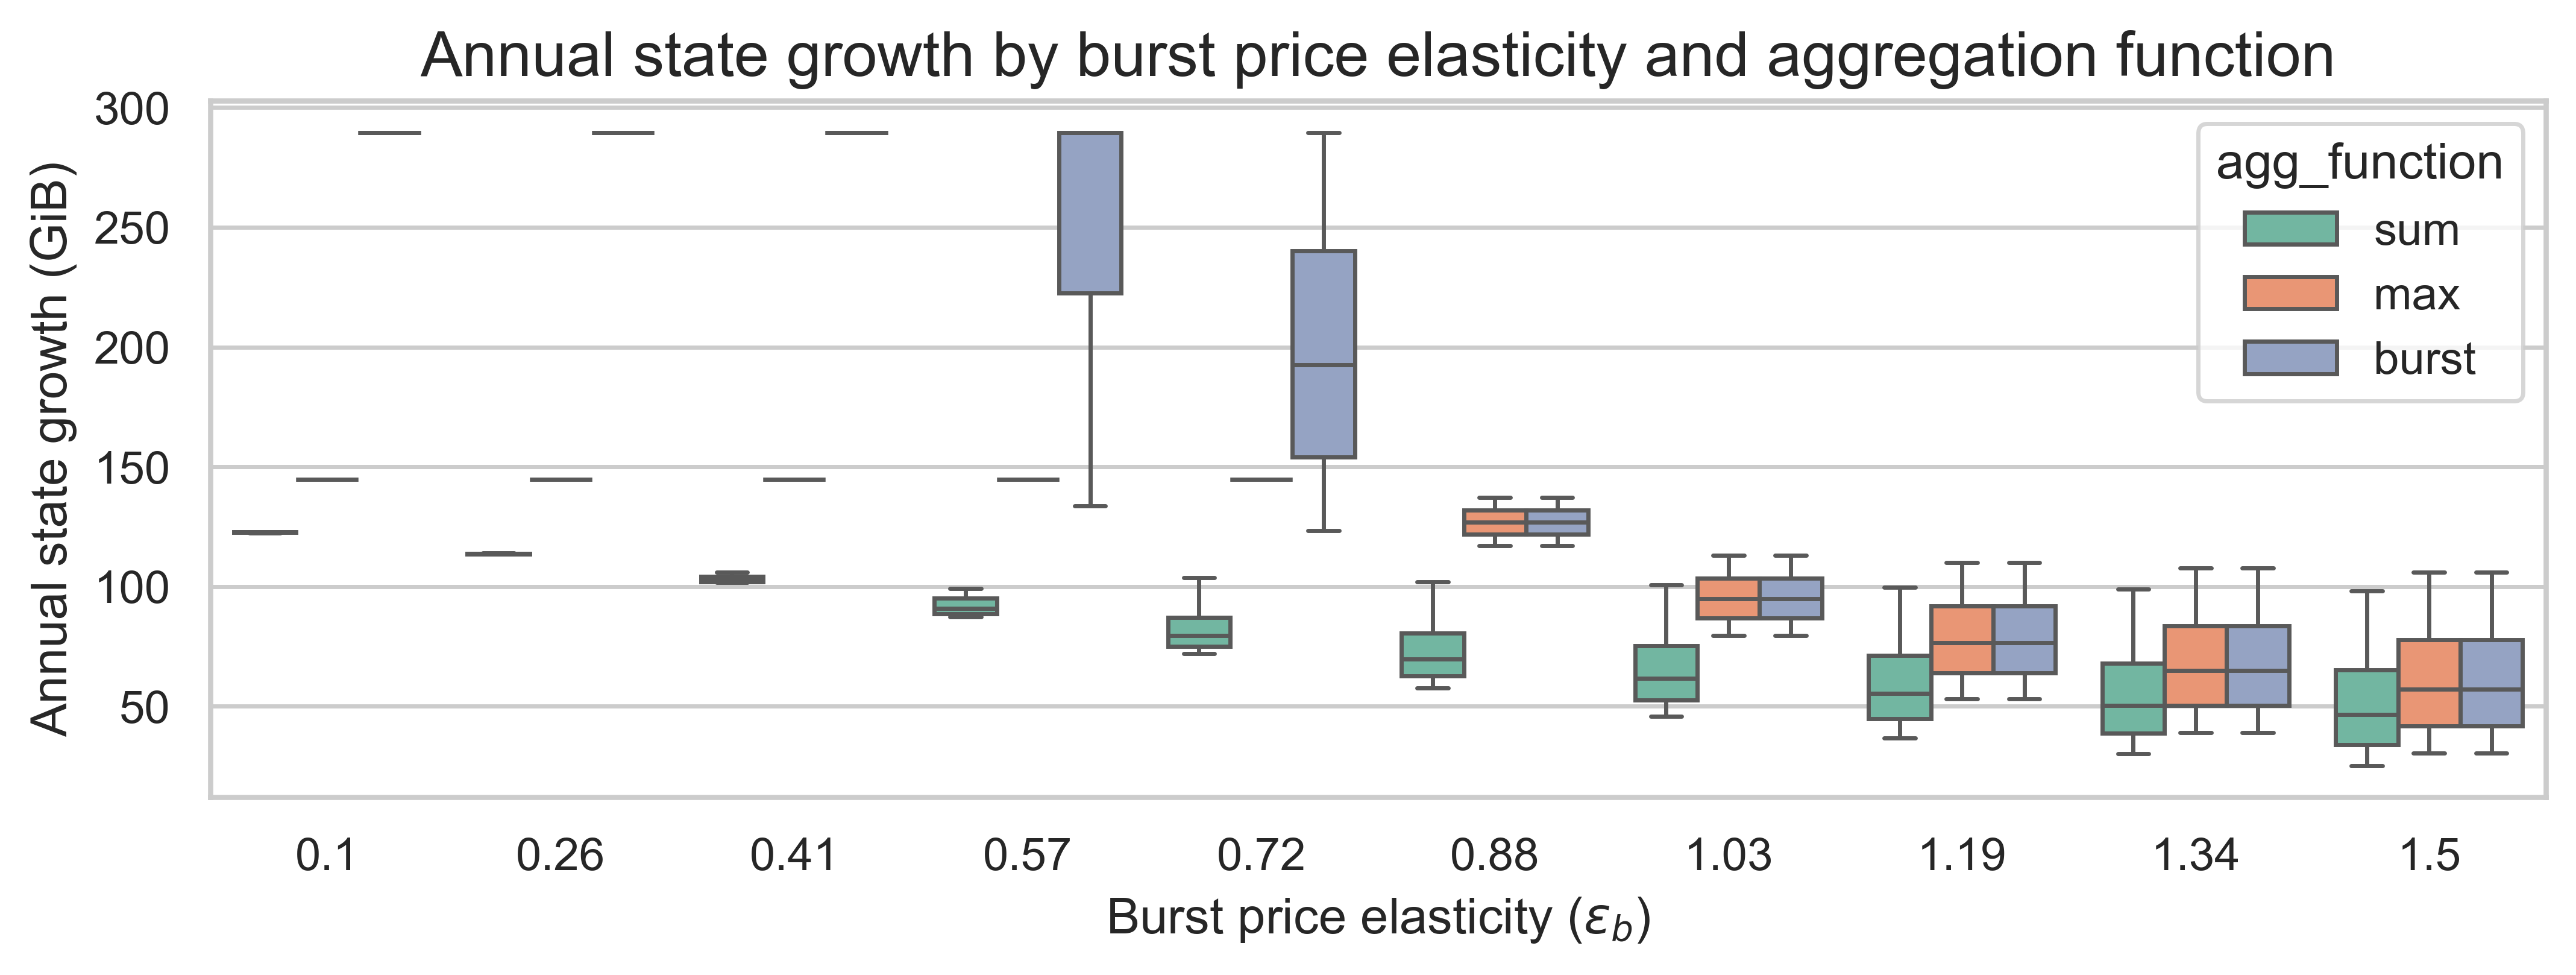

In [132]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df,
    x="eps_b",
    y="annual_state_growth_gib",
    hue="agg_function",
    showfliers=False,
)

plt.title("Annual state growth by burst price elasticity and aggregation function")
plt.ylabel("Annual state growth (GiB)")
plt.xlabel(r"Burst price elasticity ($\varepsilon_b$)")
our_file = os.path.join(our_dir, f"state_growth_by_eps_b_m={m}.png")
plt.savefig(our_file, bbox_inches="tight")
plt.show()

In [133]:
results_df.groupby("agg_function")["annual_state_growth_gib"].agg(
    ["min", "median", "max"]
)

,min,median,max
agg_function,,,
burst,30.527766,134.304363,289.611816
max,30.527766,134.304363,144.805908
sum,25.212503,85.419214,122.844203


### Impact on throughput gain

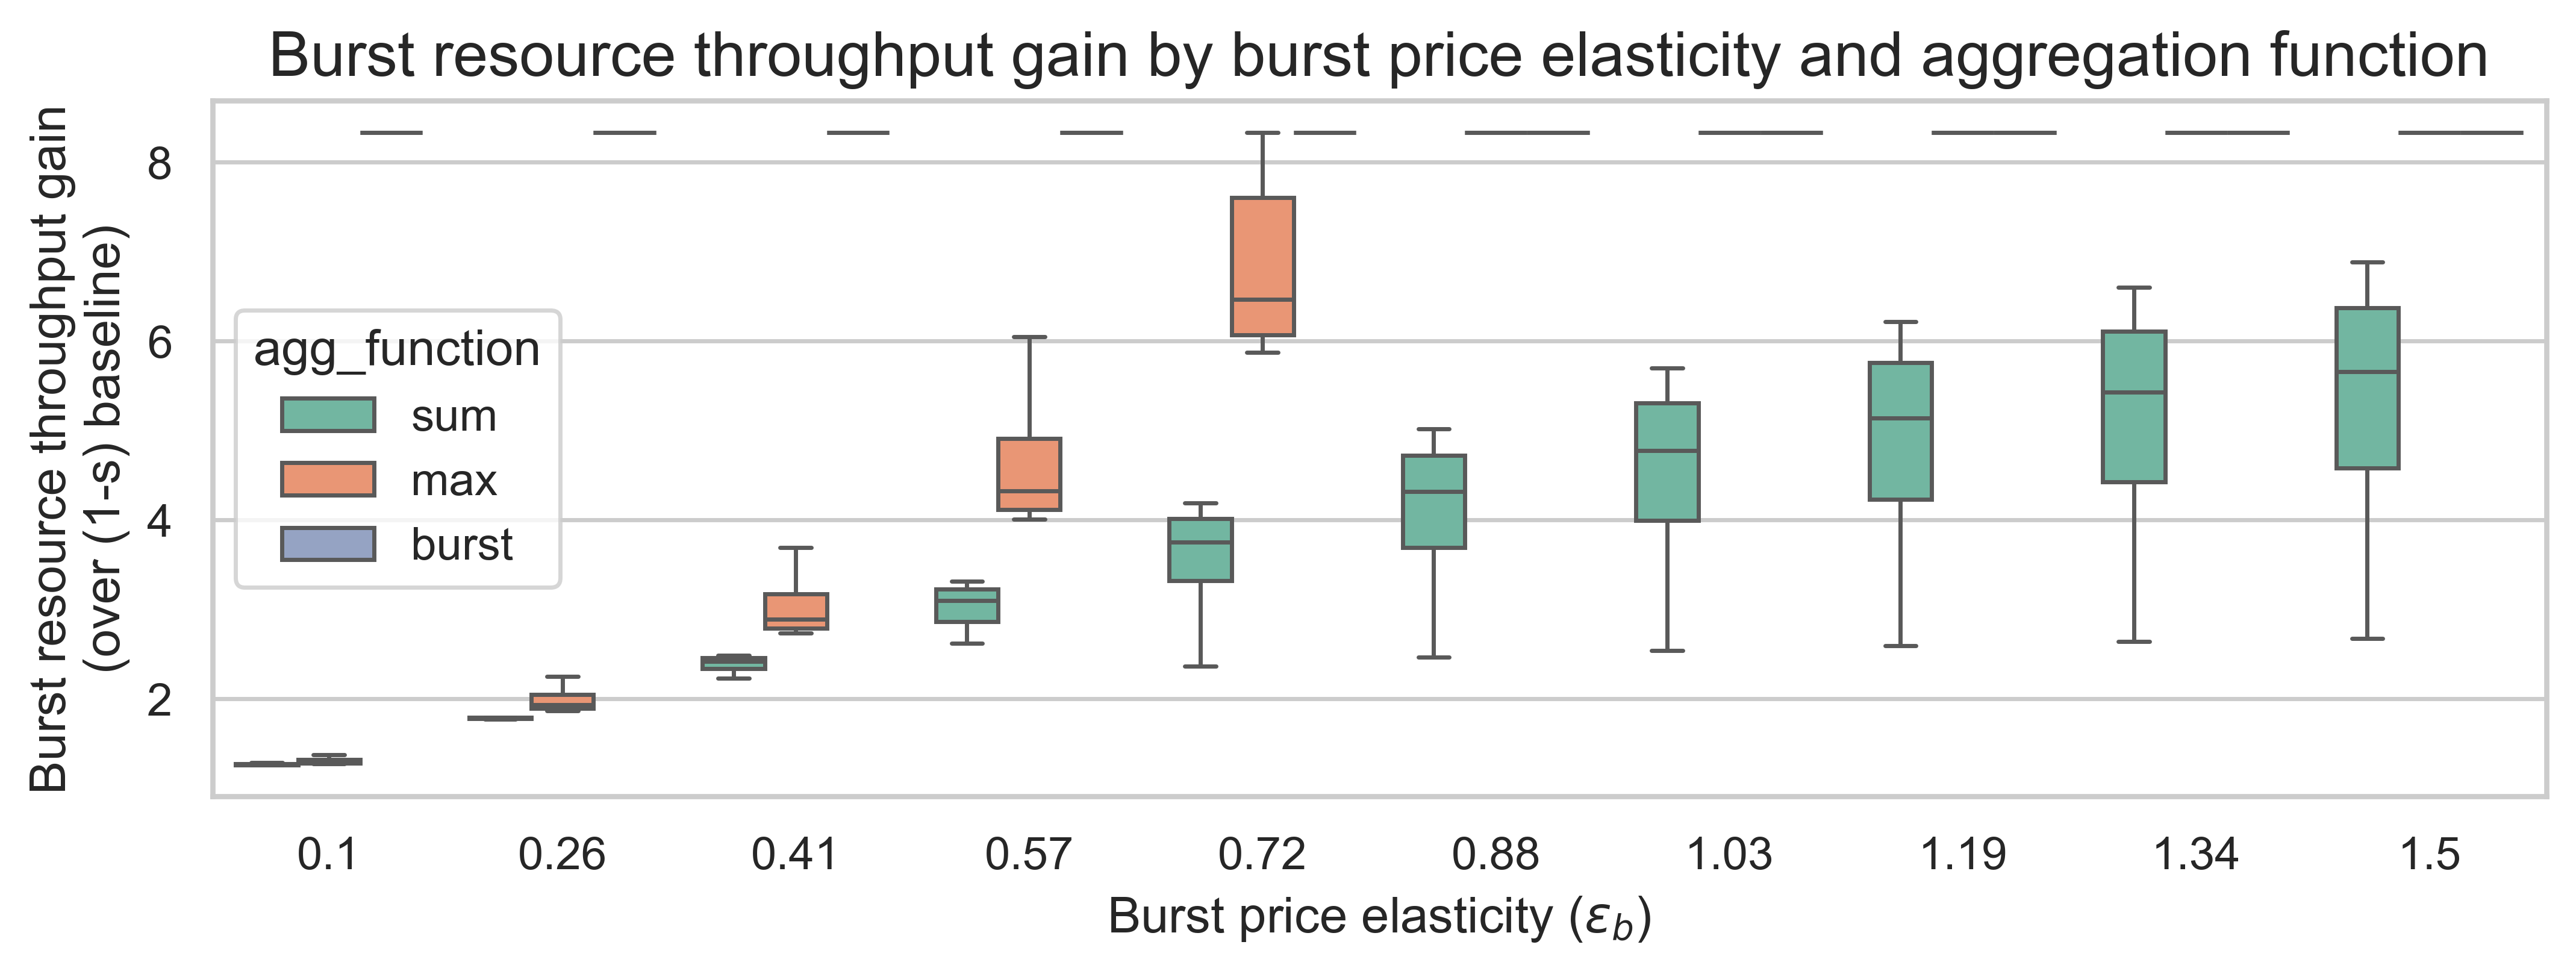

In [134]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df,
    x="eps_b",
    y="burst_throughput_gain",
    hue="agg_function",
    showfliers=False,
)

plt.title(
    "Burst resource throughput gain by burst price elasticity and aggregation function"
)
plt.ylabel("Burst resource throughput gain\n(over (1-s) baseline)")
plt.xlabel(r"Burst price elasticity ($\varepsilon_b$)")
our_file = os.path.join(our_dir, f"burst_throughput_by_eps_b_m={m}.png")
plt.savefig(our_file, bbox_inches="tight")
plt.show()

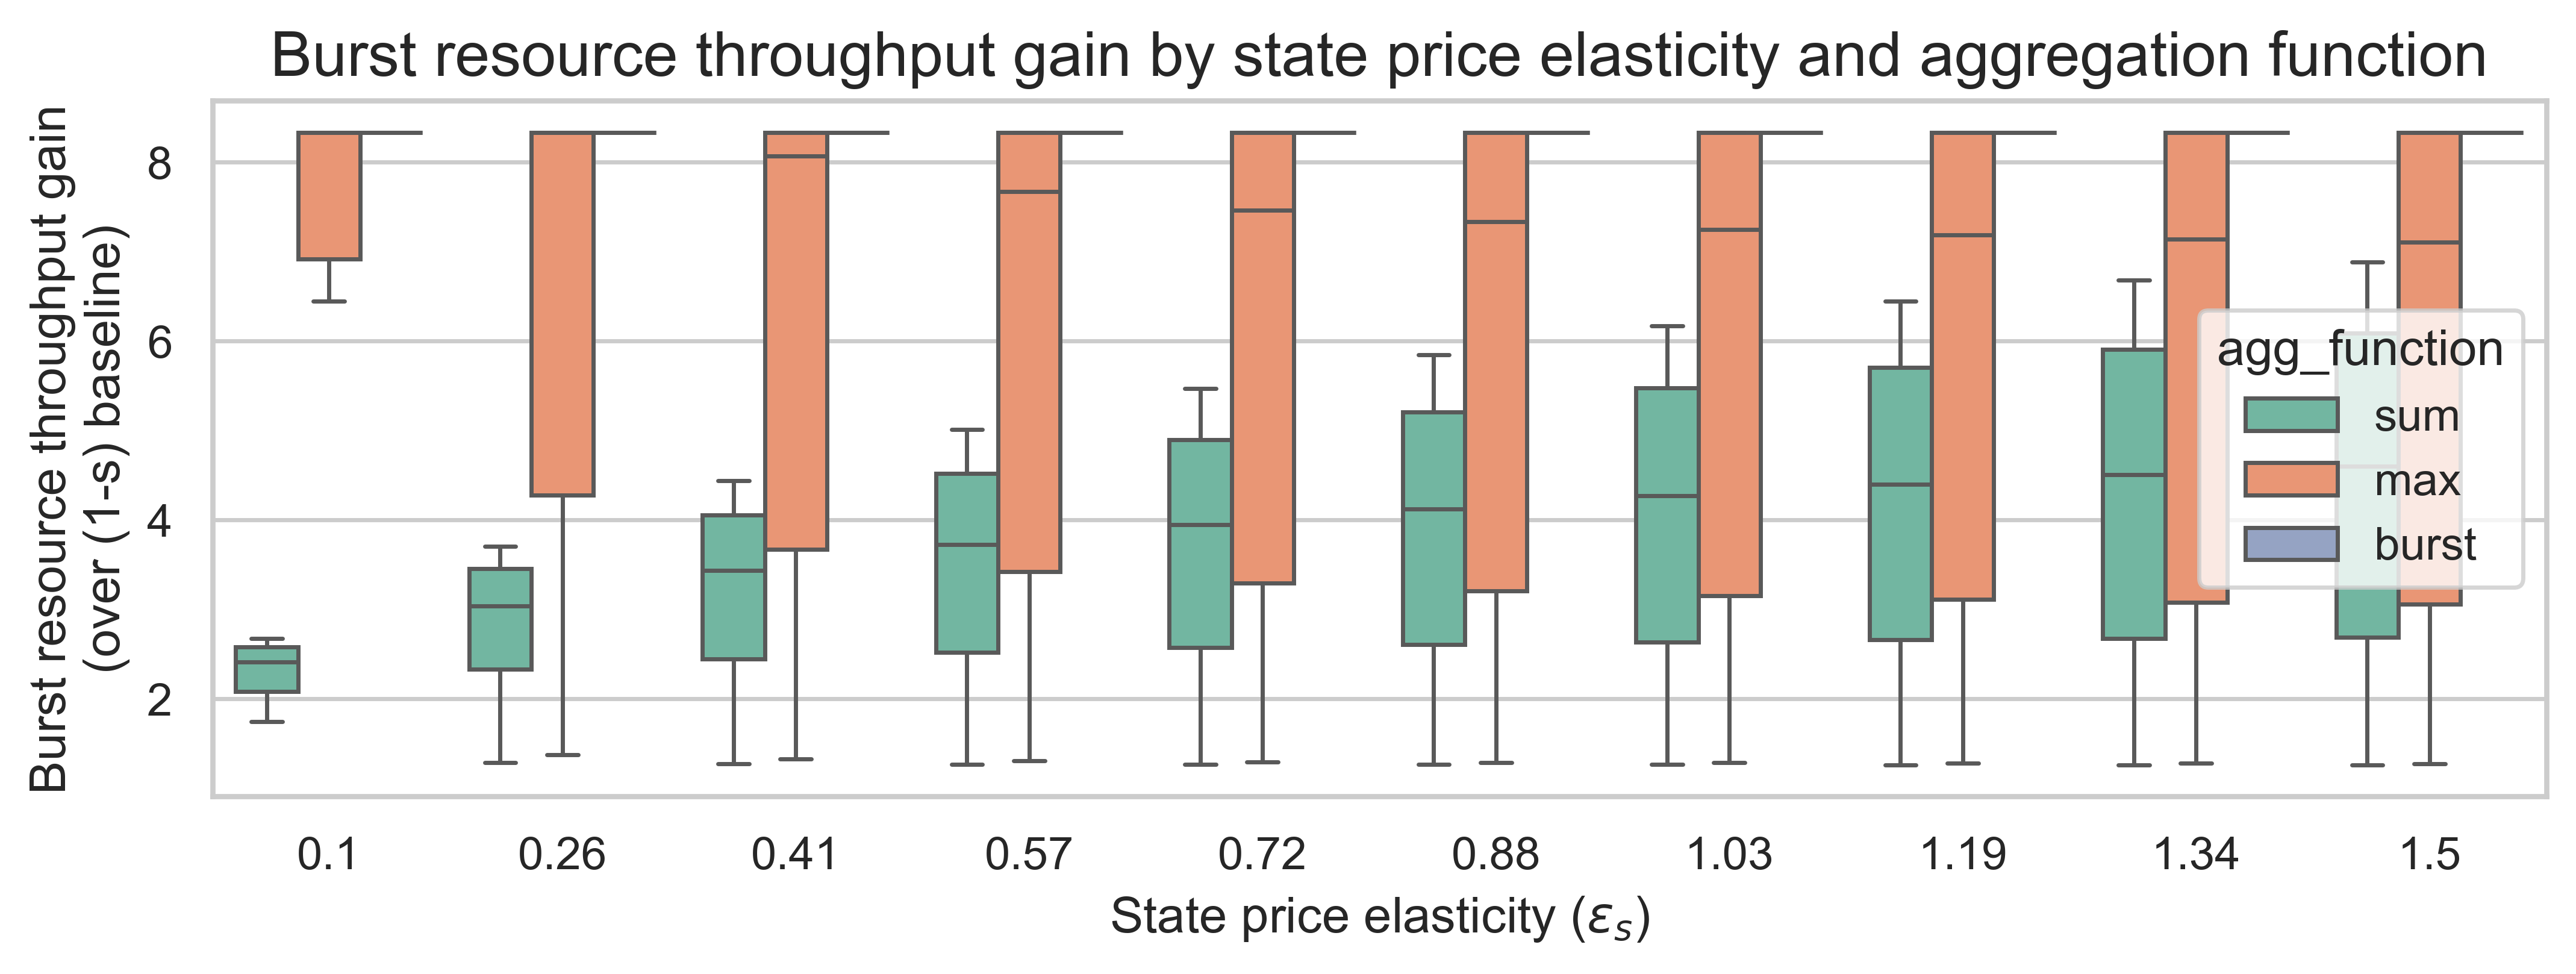

In [135]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df,
    x="eps_s",
    y="burst_throughput_gain",
    hue="agg_function",
    showfliers=False,
)

plt.title(
    "Burst resource throughput gain by state price elasticity and aggregation function"
)
plt.ylabel("Burst resource throughput gain\n(over (1-s) baseline)")
plt.xlabel(r"State price elasticity ($\varepsilon_s$)")
our_file = os.path.join(our_dir, f"burst_throughput_by_eps_s_m={m}.png")
plt.savefig(our_file, bbox_inches="tight")
plt.show()

In [136]:
results_df.groupby("agg_function")["burst_throughput_gain"].agg(
    ["min", "median", "max"]
)

,min,median,max
agg_function,,,
burst,8.333333,8.333333,8.333333
max,1.277793,8.333333,8.333333
sum,1.263859,3.417603,6.882397


In [137]:
temp_df = results_df.copy()
temp_df["high_gain"] = results_df["burst_throughput_gain"]>=5.0
temp_df.groupby("agg_function")["high_gain"].mean()

agg_function
burst    1.00
max      0.64
sum      0.23
Name: high_gain, dtype: float64

In [138]:
temp_df = results_df.copy()
temp_df["high_gain"] = results_df["burst_throughput_gain"]>=5.0
temp_df.groupby("limiting_resource")["high_gain"].mean()

limiting_resource
burst    0.902098
state    0.369427
Name: high_gain, dtype: float64

### Impact on base fee

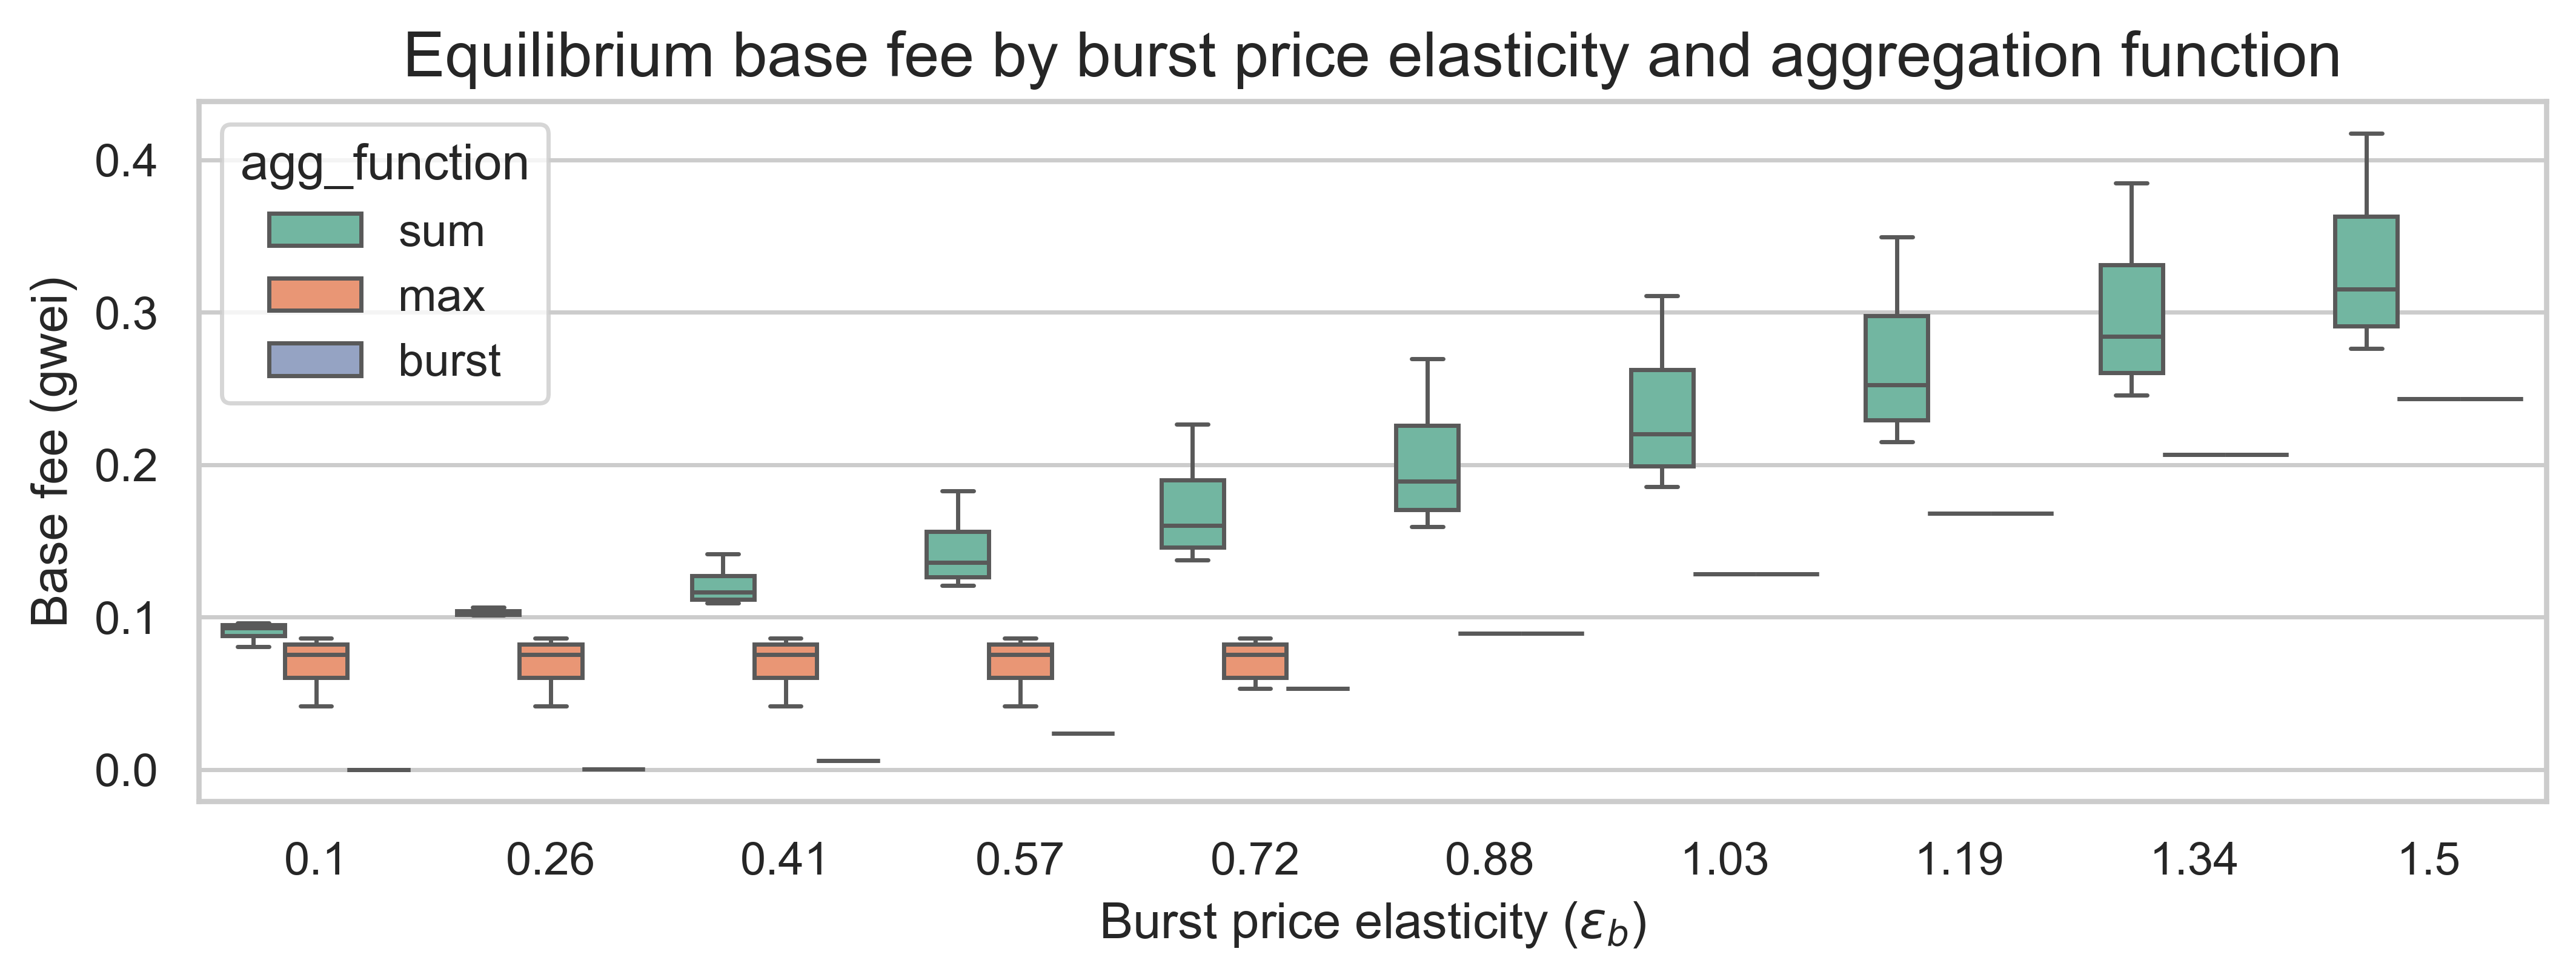

In [139]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df, x="eps_b", y="b_star", hue="agg_function", showfliers=False
)

plt.title("Equilibrium base fee by burst price elasticity and aggregation function")
plt.ylabel("Base fee (gwei)")
plt.xlabel(r"Burst price elasticity ($\varepsilon_b$)")
plt.show()

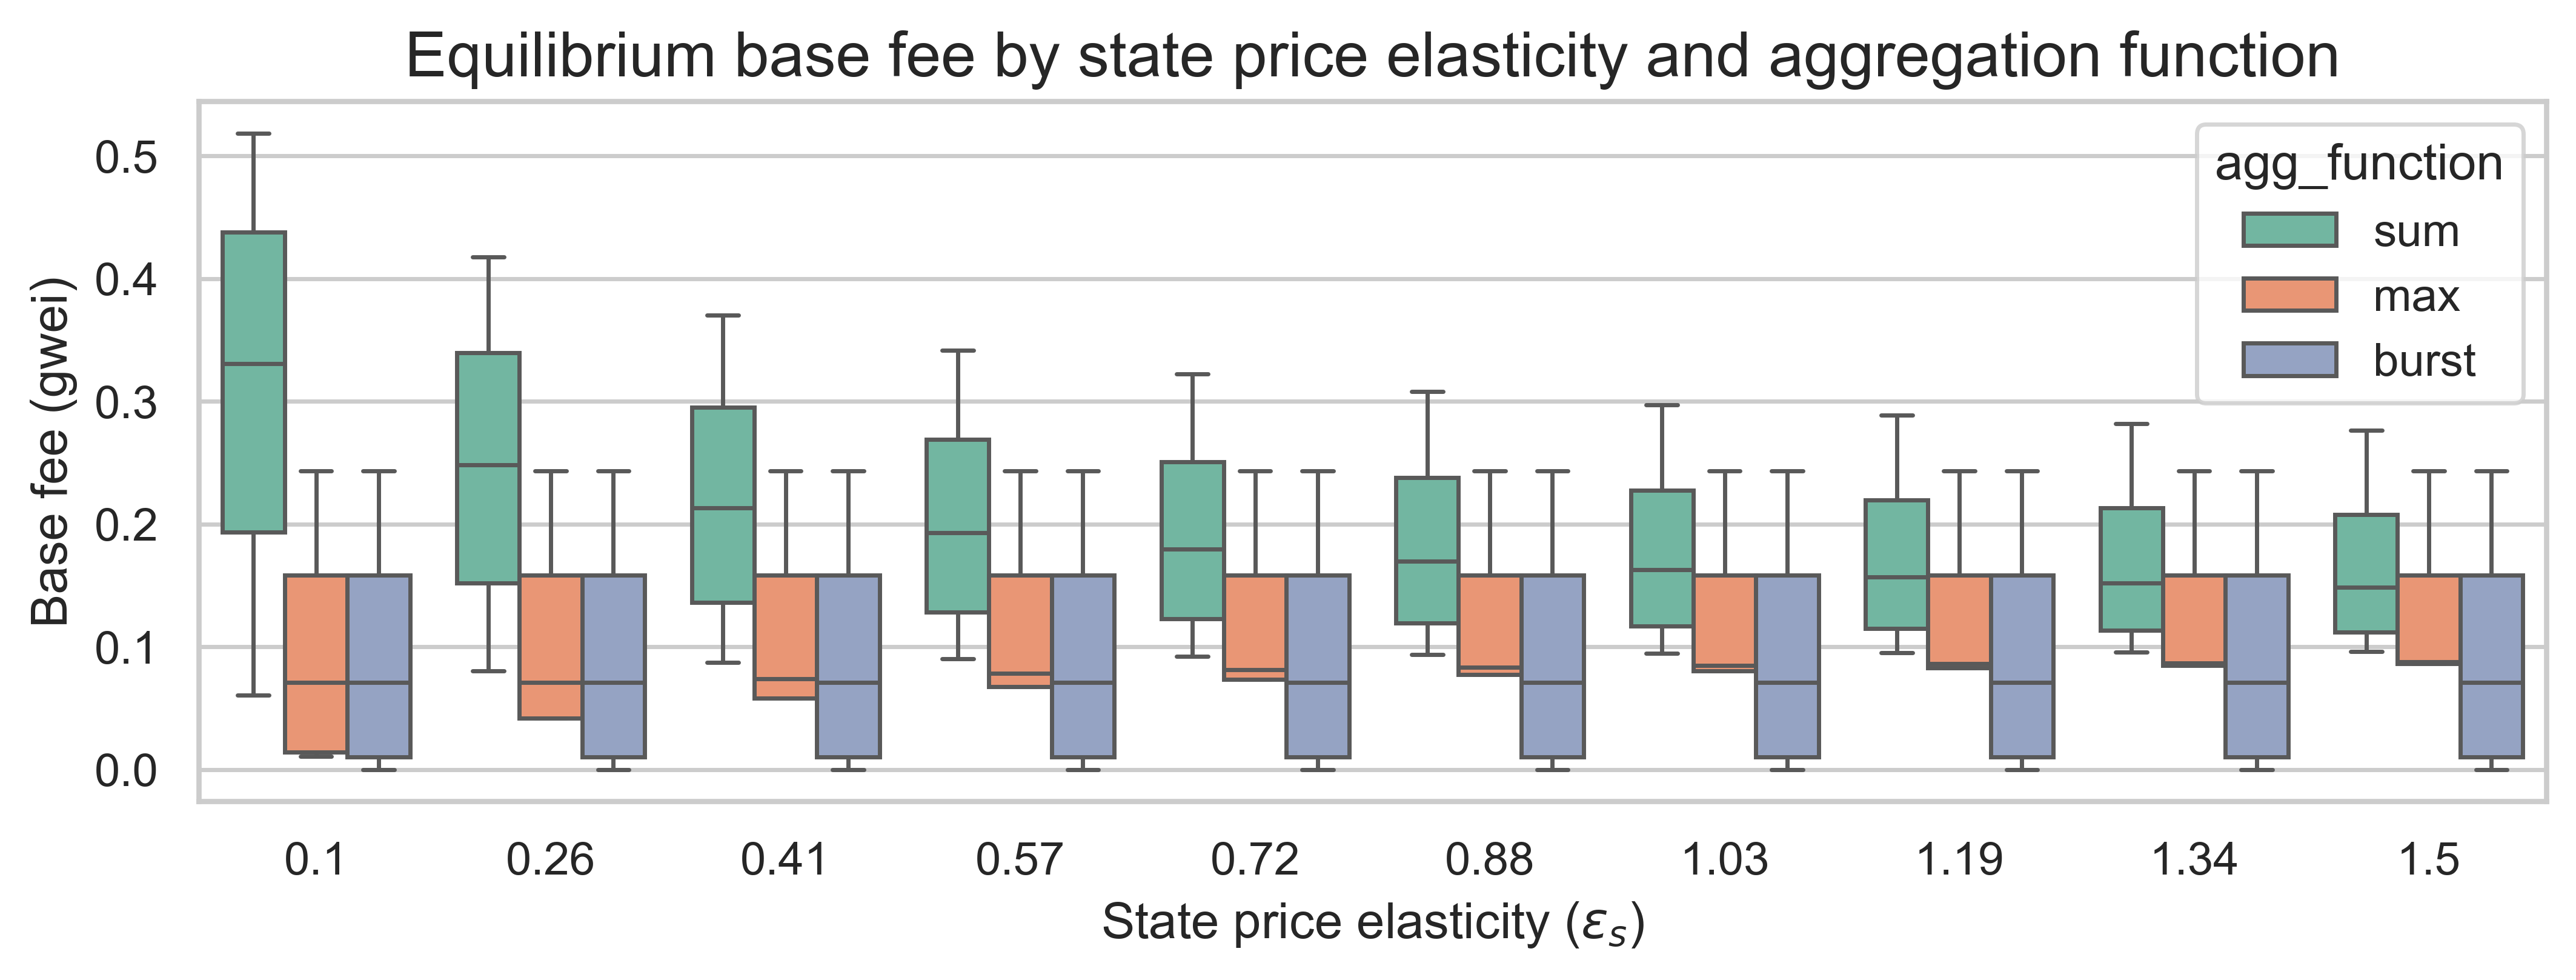

In [140]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df, x="eps_s", y="b_star", hue="agg_function", showfliers=False
)

plt.title("Equilibrium base fee by state price elasticity and aggregation function")
plt.ylabel("Base fee (gwei)")
plt.xlabel(r"State price elasticity ($\varepsilon_s$)")
plt.show()

### Impact on burst share

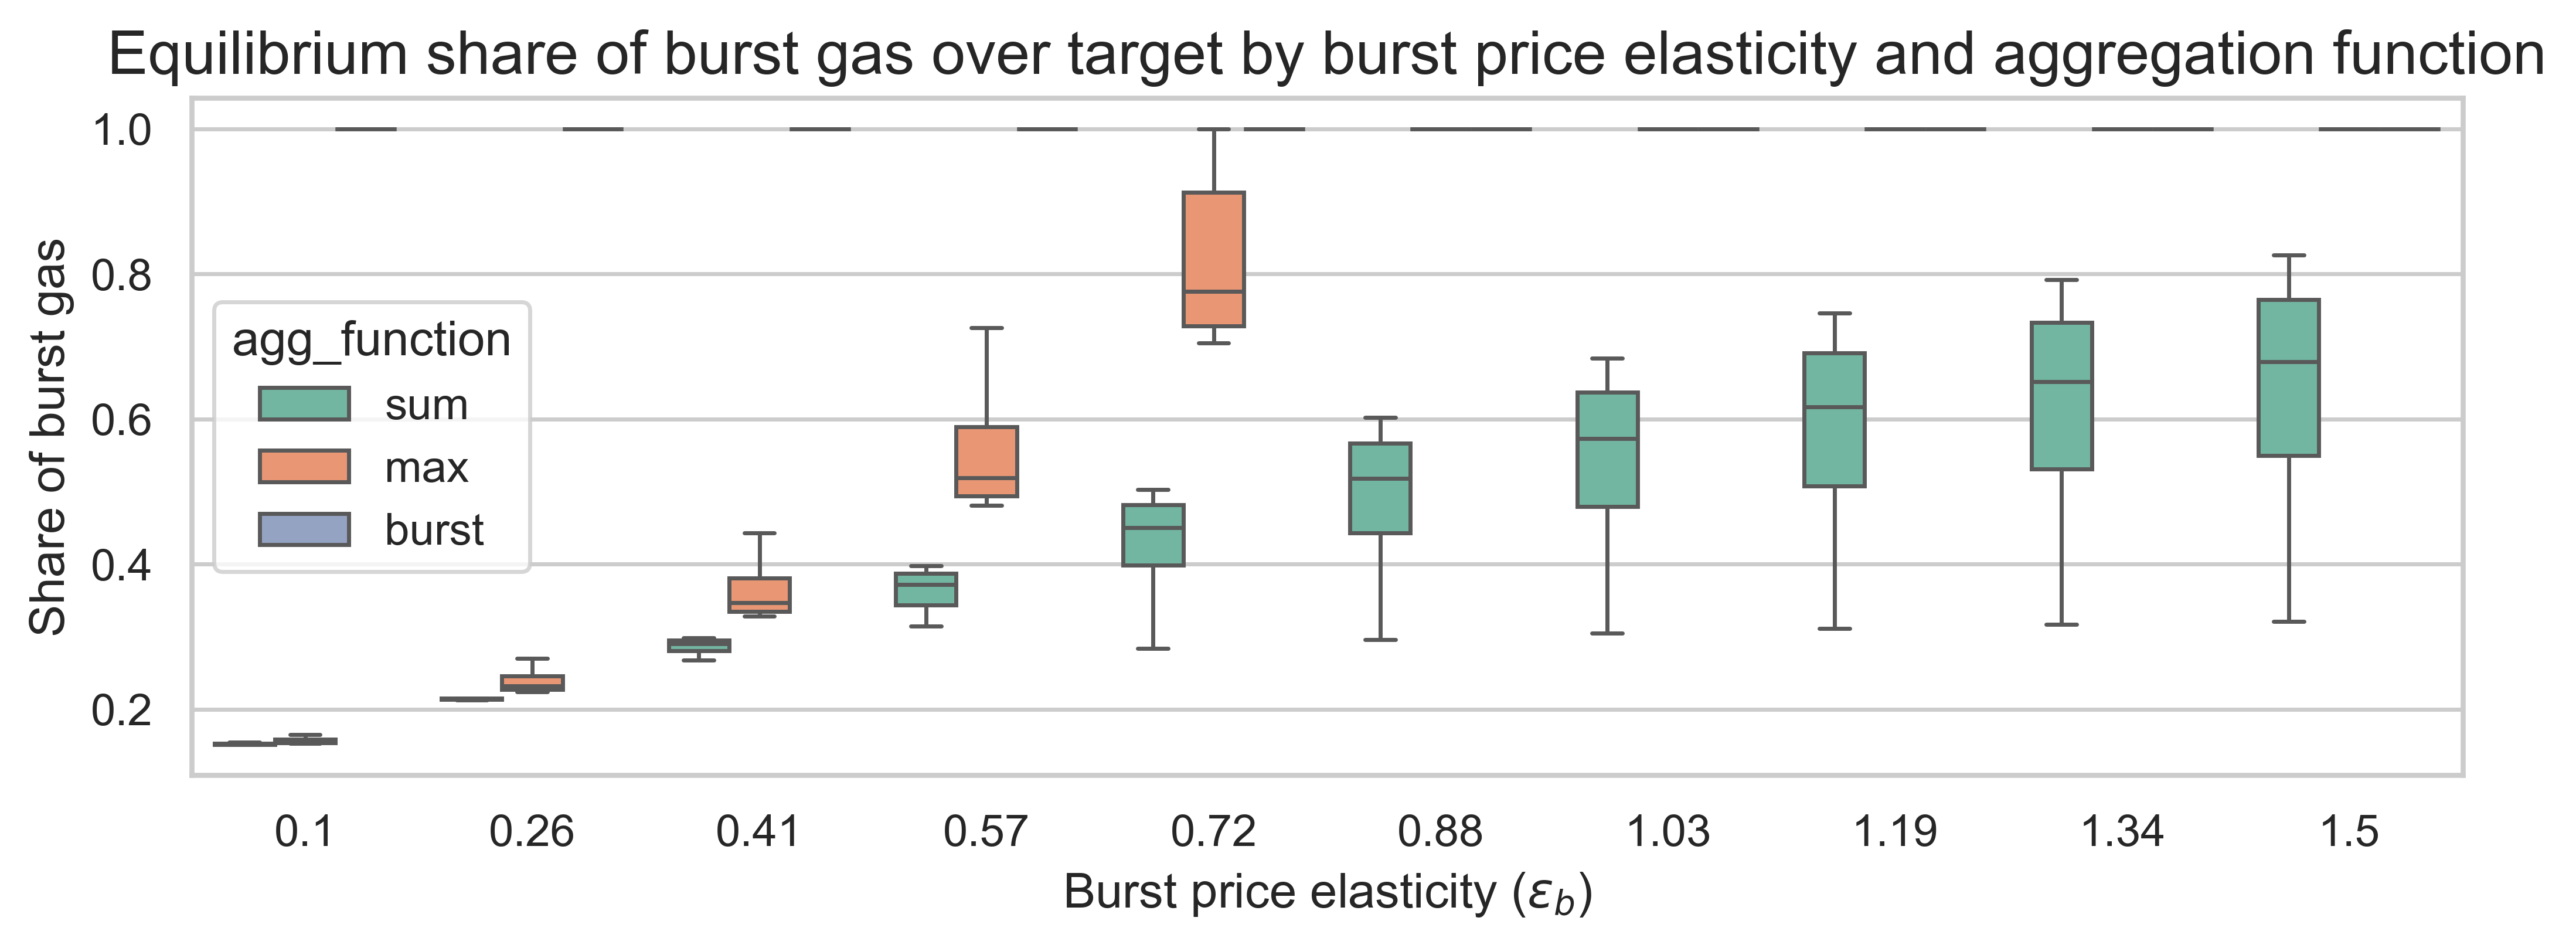

In [141]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df, x="eps_b", y="share_burst", hue="agg_function", showfliers=False
)

plt.title(
    "Equilibrium share of burst gas over target by burst price elasticity and aggregation function"
)
plt.ylabel("Share of burst gas")
plt.xlabel(r"Burst price elasticity ($\varepsilon_b$)")
plt.show()

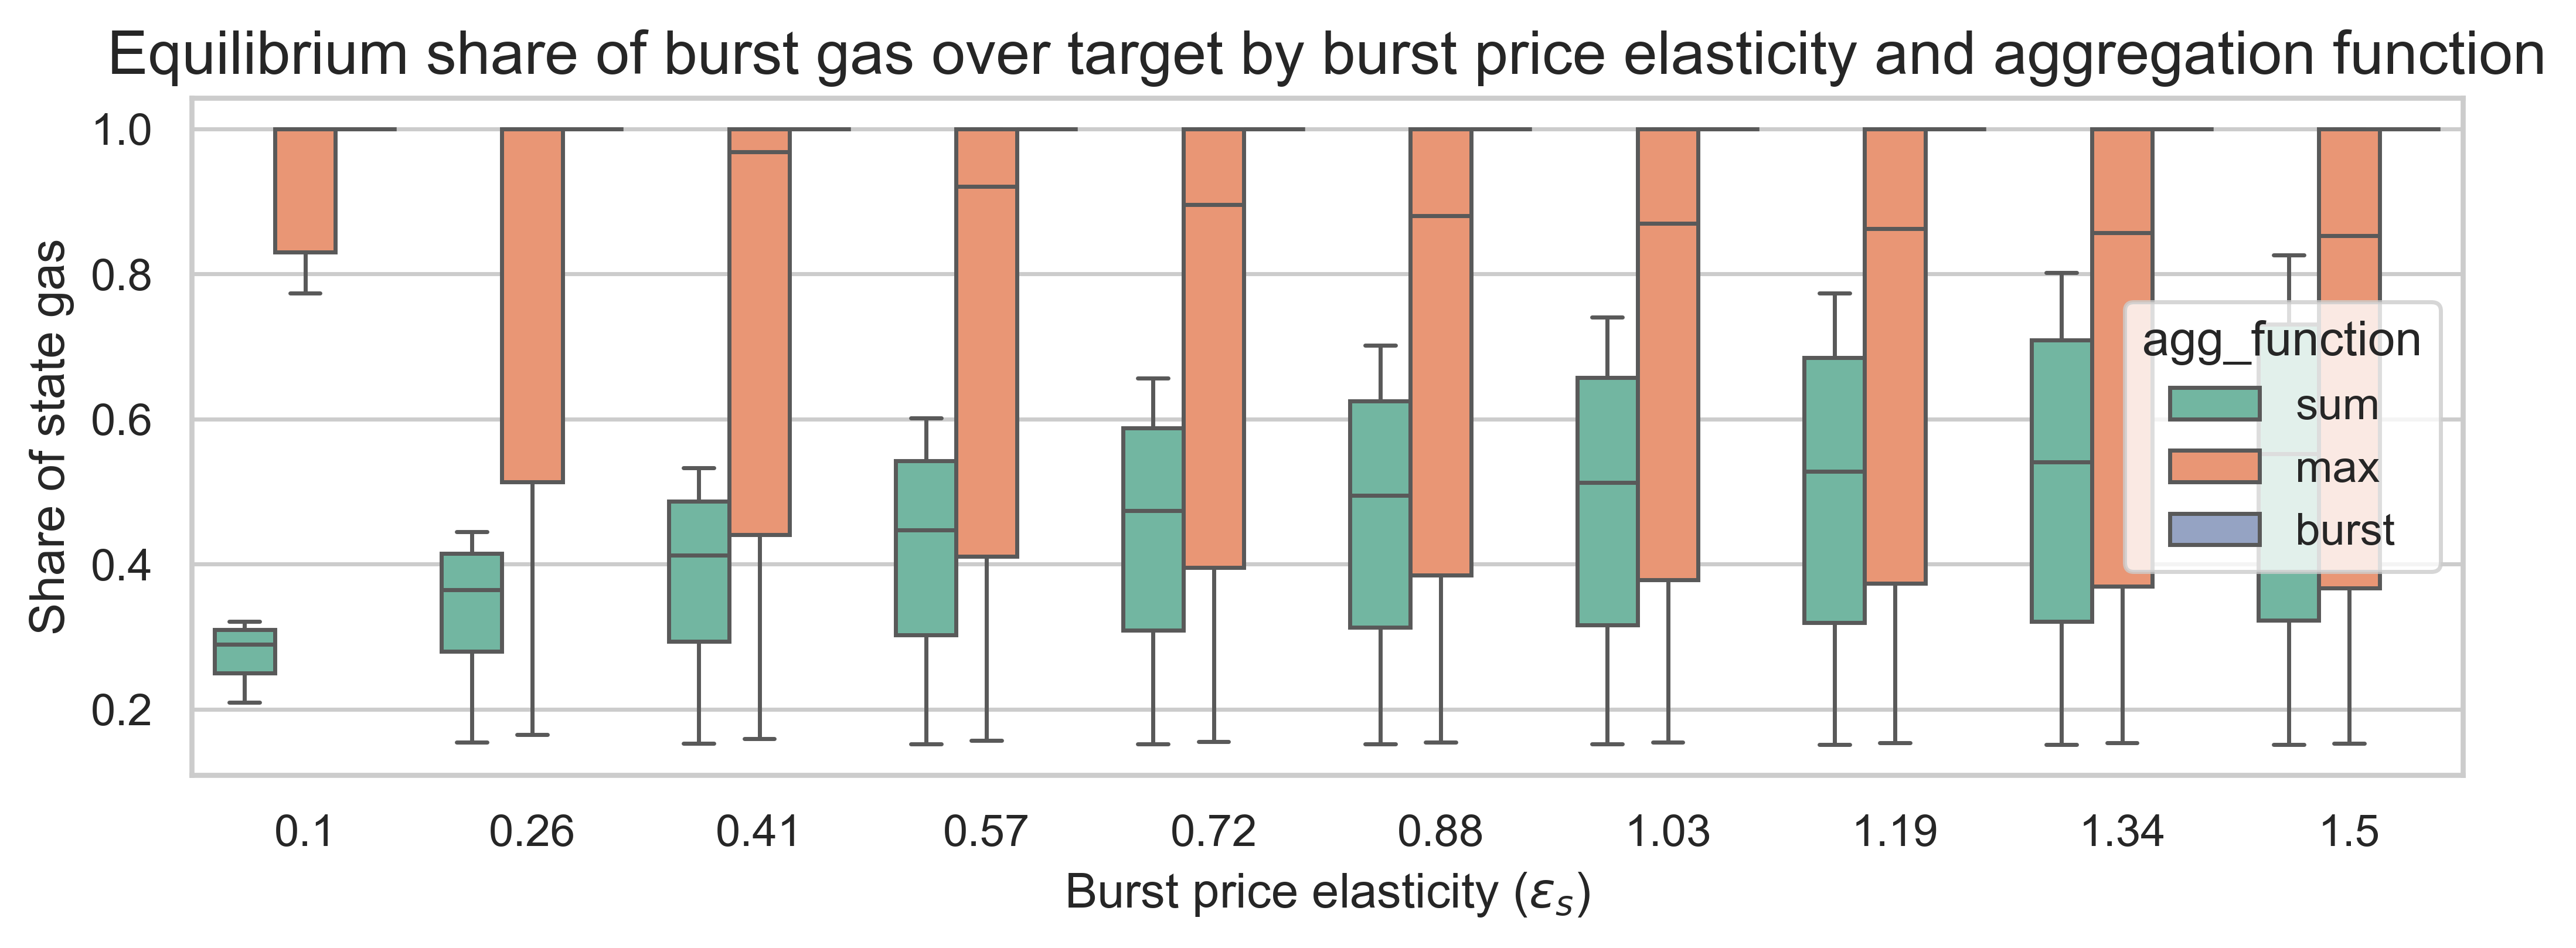

In [142]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=results_df, x="eps_s", y="share_burst", hue="agg_function", showfliers=False
)

plt.title(
    "Equilibrium share of burst gas over target by burst price elasticity and aggregation function"
)
plt.ylabel("Share of state gas")
plt.xlabel(r"Burst price elasticity ($\varepsilon_s$)")
plt.show()